# Taller 2 — Modelos y Simulación
## Decisiones de capacidad en una plataforma de CI/CD mediante DES y Monte Carlo

> **Este taller se debe realizar en parejas. A cualquier estudiante se le puede solicitar que defienda de forma oral la solución, incluyendo el modelo, el código, los experimentos y las conclusiones. Ambos integrantes deben comprender y poder explicar la totalidad del trabajo entregado.**

**Producto:** este Jupyter Notebook completado con código, resultados, pruebas e interpretación.  
**Valoración:** 100 puntos, distribuidos en diez ejercicios.

**Integrante 1:** Lina Paola Suarez Diaz

**Integrante 2:** Juan José Alvarez Gonzalez

En este taller asumirán el papel de un equipo de analítica de operaciones. Deberán implementar una simulación de eventos discretos, diseñar experimentos reproducibles y utilizar Monte Carlo para recomendar una configuración de infraestructura bajo incertidumbre.

### Contexto y decisión

En una empresa de software, cada cambio de código dispara un trabajo (*job*) en la plataforma de integración y entrega continuas, **CI/CD**. Antes de autorizar el cambio, la plataforma debe compilarlo, ejecutar pruebas y, en algunos casos, hacer un análisis de seguridad. Si las pruebas fallan, se realiza un único retrabajo. Los equipos reportan que las colas durante las horas de mayor actividad retrasan sus entregas.

La dirección puede contratar agentes de compilación, ejecutores de pruebas y escáneres de seguridad. Aumentar capacidad cuesta dinero; ubicarla en la etapa equivocada puede aportar poco beneficio. Además, la demanda y los tiempos de procesamiento cambian entre jornadas.

**Pregunta de decisión:** ¿qué configuración ofrece un compromiso defendible entre costo diario, cumplimiento del SLA y riesgo de retrasos, y qué tan robusta es la recomendación cuando las entradas son inciertas?

El caso retoma el contexto del taller de años previos, pero añade varias actividades, recursos distintos, rutas probabilísticas, retrabajo, cierre de jornada, comparación estadística y evaluación económica. **El proceso corresponde a un problema operativo real; los parámetros siguientes son datos sintéticos definidos para el ejercicio, no mediciones de una empresa.** No se requiere consultar servicios externos ni recolectar datos adicionales para resolverlo.

### 1. Proceso que deben representar

Cada trabajo es una entidad identificable. Su recorrido es:

![Proceso que deben representar](Flujo_de_compilación_y_pruebas.png)

- Todos los trabajos pasan por compilación inicial y pruebas.
- Al terminar las primeras pruebas, un trabajo falla con probabilidad $p_f=0.12$. En ese caso solicita nuevamente un agente de compilación y luego un ejecutor de pruebas. **Solo se permite un retrabajo; las segundas pruebas se consideran aprobadas.** El retrabajo pertenece al mismo trabajo, no es una llegada externa nueva.
- Independientemente del fallo, cada trabajo requiere seguridad con probabilidad $p_s=0.30$. El análisis se hace **una sola vez**, después de aprobar las pruebas.
- Cada etapa usa un recurso distinto. El recurso se libera al terminar su actividad, antes de esperar el siguiente. No se retiene un agente de compilación mientras se espera por pruebas.
- Las colas tienen capacidad ilimitada y disciplina **FIFO**. Los retrabajos se incorporan al final de la cola correspondiente. No hay prioridades, cancelaciones, interrupciones ni fallas físicas de los servidores en el modelo obligatorio.

### 2. Datos operativos y alternativas

La unidad de tiempo es el **minuto**. Las llegadas externas ocurren durante $[0,480)$ y siguen un proceso de Poisson con tasa constante dentro de cada intervalo. En el caso nominal, el multiplicador diario de demanda es $D=1$.

| Intervalo desde la apertura | Tasa nominal $\lambda(t)$, trabajos/minuto | Tasa equivalente, trabajos/hora |
|---|---:|---:|
| $[0,120)$ | 0.12 | 7.2 |
| $[120,240)$ | 0.25 | 15.0 |
| $[240,360)$ | 0.18 | 10.8 |
| $[360,480)$ | 0.10 | 6.0 |

Para un día con demanda $D$, la tasa es $D\lambda(t)$. En cada tramo, el tiempo entre llegadas tiene media $1/(D\lambda)$. No debe producirse automáticamente un trabajo en el minuto cero.

| Actividad | Distribución | Media aritmética, min | Desviación estándar, min | Parámetros adicionales |
|---|---|---:|---:|---|
| Compilación inicial | Lognormal | 12 | 6 | — |
| Compilación correctiva | Lognormal | 6 | 3 | Solo si hay retrabajo. |
| Primeras pruebas | Lognormal | 8 | 4 | — |
| Segundas pruebas | Lognormal | 8 | 4 | Solo si hay retrabajo. |
| Seguridad | Triangular | A calcular | A calcular | mínimo 4, moda 6, máximo 12. |

En el caso nominal el factor de lentitud es $\Theta=1$. En los experimentos bajo incertidumbre, **todas las duraciones de actividad se multiplican por $\Theta$**, manteniendo los mismos sorteos básicos. Condicionalmente a los parámetros de cada experimento, los tiempos de actividad, las decisiones de ruta y las llegadas se modelan independientes.

| Política | Agentes de compilación | Ejecutores de pruebas | Escáneres de seguridad |
|---|---:|---:|---:|
| P0 — Actual | 2 | 2 | 1 |
| P1 — Más compilación | 3 | 2 | 1 |
| P2 — Más pruebas | 2 | 3 | 1 |
| P3 — Ampliación balanceada | 3 | 3 | 1 |
| P4 — Compilación reforzada | 4 | 2 | 1 |

No presupongan que la alternativa con mayor capacidad, mayor utilización o menor espera media será la decisión más conveniente.

### 3. Cierre, medición y reproducibilidad

1. Cada jornada comienza **vacía**, sin trabajos heredados. Este es un estudio de jornadas finitas; no se solicita un período de calentamiento ni una estimación de estado estacionario.
2. Después del minuto 480 no hay nuevas llegadas. Los recursos continúan atendiendo hasta completar **todos** los trabajos que llegaron antes del cierre. Las esperas y los tiempos totales se calculan sobre esa cohorte completa.
3. El *backlog* al cierre cuenta trabajos con llegada menor que 480 y salida mayor que 480. El throughput operativo cuenta salidas hasta el minuto 480 y se divide entre 8 horas. No usen las salidas del período posterior al cierre en ese throughput.
4. La utilización operativa se mide solo en $[0,480]$: sumen el tiempo ocupado que cae dentro de esta ventana y dividan por $480$ multiplicado por la capacidad del recurso. Deben recortar correctamente las actividades que cruzan el cierre. Pueden reportar una utilización durante el vaciado como métrica adicional, con otro denominador explícito.
5. Al comparar políticas en una repetición, usen **la misma lista de trabajos, las mismas llegadas, rutas y duraciones de actividad**. Generen esas entradas antes de ejecutar las políticas. Sortear en el orden de atención puede cambiar la asociación entre trabajo y duración cuando cambia la capacidad.
6. Usen `numpy.random.Generator`, semillas reproducibles y flujos separados para llegadas, compilación, pruebas, seguridad y las dos decisiones de ruta. No reinicialicen un generador con la misma semilla para cada trabajo.
7. Documenten el orden de procesamiento de eventos simultáneos y manténganlo reproducible. En SimPy pueden usar su orden de programación de eventos. Las pruebas deben evitar depender de desempates no especificados.

**Caso sin llegadas:** los conteos y el costo fijo/de capacidad se reportan normalmente; medias, percentiles y proporciones por trabajo se marcan como `NaN`. No inventen un cumplimiento de SLA del 100 %. Informen cuántas jornadas sin llegadas aparecen y cómo las tratan en los resúmenes.

### 4. Indicadores y modelo económico

Para cada trabajo $j$, registren:

- $W_j$: tiempo desde su llegada hasta el inicio de la **primera compilación**. Cumple el SLA si $W_j<10$ minutos.
- Espera en cada visita a cada recurso, diferenciando primer intento y retrabajo.
- $T_j$: tiempo desde llegada hasta salida final. Se considera retrasado si $T_j>60$ minutos.
- Ruta seguida, número de visitas a cada etapa y tiempo de salida.

Por jornada, reporten al menos media y p90 de $W_j$; media y p95 de $T_j$; proporción que cumple el SLA; proporción con $T_j>60$; throughput hasta el cierre; backlog; utilización de cada recurso; número de retrabajos; y minutos necesarios para vaciar el sistema después del cierre.

El **evento de riesgo operativo** para los ejercicios 8–9 es

$$R=\left\{\frac{1}{N}\sum_{j=1}^{N}\mathbf{1}(T_j>90)>0.20\right\}.$$

Si $N=0$, definan $\mathbf{1}(R)=0$: ese día no hubo trabajos retrasados. Esta convención no cambia la regla anterior para proporciones por trabajo.

El costo diario, en **pesos colombianos (COP)**, combina infraestructura y una valoración interna de los retrasos:

$$
C_p=90\,000 + K(480+V_p)(300n_{b,p}+220n_{t,p}+350n_{s,p})
      + A\sum_{j=1}^{N}W_{j,p}+B\sum_{j=1}^{N}\mathbf{1}(T_{j,p}>60).
$$

- $n_b,n_t,n_s$: capacidades contratadas por la política.
- $V_p=\max(0,\max_j t_{salida,j,p}-480)$: minutos de vaciado; si no hay trabajos, $V_p=0$.
- Las tarifas son 300 COP/min por agente de compilación, 220 por ejecutor de pruebas y 350 por escáner. **Toda la capacidad contratada se cobra durante la jornada y el vaciado**, aunque algunos recursos estén ociosos.
- $K$ es un multiplicador de tarifas; $A$ se mide en COP por minuto de espera inicial acumulada y $B$ en COP por trabajo retrasado. No se aplica $A$ a las esperas del retrabajo.
- Valores nominales: $K=1$, $A=200$, $B=20\,000$.

Los dos últimos términos representan una valoración de impacto empresarial, no una factura del proveedor. Expliquen esta diferencia cuando recomienden una política.

### Preparación y reglas de entrega

Utilicen Python 3 y `numpy`, `pandas`, `scipy`, `matplotlib` y `simpy`. Si su entorno no tiene estos paquetes, instálenlos antes de trabajar; desde una celda de Jupyter pueden usar `%pip install numpy pandas scipy matplotlib simpy`. `fitter` y `sim-tools` son opcionales.

- Respondan los ejercicios dentro de este notebook. Cada ejercicio práctico debe contener **implementación, resultados e interpretación**.
- El notebook terminado debe ejecutar con **Restart Kernel and Run All** sin errores ni dependencia del orden previo de ejecución.
- El código suministrado organiza entradas e interfaces. **Las funciones pendientes son plantillas, no una solución**; sus llamadas están comentadas para que la plantilla pueda abrirse y ejecutarse antes de completarla.
- Pueden añadir celdas y funciones. Conserven la identificación de los diez ejercicios y documenten cualquier cambio de interfaz.
- Toda tabla y gráfica debe identificar política, unidades y tamaño del experimento. Distingan un percentil de tiempos individuales de un percentil de promedios diarios.
- Declaren supuestos adicionales, indiquen las fuentes del código adaptado y expliquen cualquier apoyo externo utilizado. Ambos integrantes deben poder defender las decisiones y el código.
- Entreguen un archivo llamado `Taller2_Apellido1_Apellido2.ipynb`, con sus resultados visibles. No se exige un informe separado, conexión a una plataforma de CI/CD ni archivos de datos externos.

In [1]:
from dataclasses import dataclass, replace
from time import perf_counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats, integrate
!pip install simpy
import simpy

SEMILLA_MAESTRA = 20261001

@dataclass(frozen=True)
class Configuracion:
    horizonte: float = 480.0
    demanda: float = 1.0
    lentitud: float = 1.0
    p_retrabajo: float = 0.12
    p_seguridad: float = 0.30
    multiplicador_tarifa: float = 1.0
    costo_espera: float = 200.0
    costo_retraso: float = 20_000.0

@dataclass(frozen=True)
class Politica:
    nombre: str
    n_compilacion: int
    n_pruebas: int
    n_seguridad: int

CONFIG_NOMINAL = Configuracion()
POLITICAS = {
    'P0': Politica('P0', 2, 2, 1),
    'P1': Politica('P1', 3, 2, 1),
    'P2': Politica('P2', 2, 3, 1),
    'P3': Politica('P3', 3, 3, 1),
    'P4': Politica('P4', 4, 2, 1),
}

TRAMOS_LLEGADAS = pd.DataFrame({
    'inicio': [0.0, 120.0, 240.0, 360.0],
    'fin': [120.0, 240.0, 360.0, 480.0],
    'tasa_nominal': [0.12, 0.25, 0.18, 0.10],
})

ACTIVIDADES_LOGNORMALES = {
    'compilacion_1': (12.0, 6.0),
    'compilacion_2': (6.0, 3.0),
    'pruebas_1': (8.0, 4.0),
    'pruebas_2': (8.0, 4.0),
}

error: externally-managed-environment

× This environment is externally managed
╰─> To install Python packages system-wide, try apt install
    python3-xyz, where xyz is the package you are trying to
    install.
    
    If you wish to install a non-Debian-packaged Python package,
    create a virtual environment using python3 -m venv path/to/venv.
    Then use path/to/venv/bin/python and path/to/venv/bin/pip. Make
    sure you have python3-full installed.
    
    If you wish to install a non-Debian packaged Python application,
    it may be easiest to use pipx install xyz, which will manage a
    virtual environment for you. Make sure you have pipx installed.
    
    See /usr/share/doc/python3.14/README.venv for more information.

note: If you believe this is a mistake, please contact your Python installation or OS distribution provider. You can override this, at the risk of breaking your Python installation or OS, by passing --break-system-packages.
hint: See PEP 668 for the detai

## Ejercicio 1 — Especificación y protocolo experimental · 8 puntos

Antes de programar:

1. Definan la frontera del sistema, las entidades, los recursos, las colas, los eventos y las variables de estado. Incluyan una tabla con al menos ocho elementos, su papel y su unidad.
2. Expliquen por qué el modelo operativo es dinámico, estocástico y de eventos discretos. Diferencien ese modelo del experimento Monte Carlo usado para evaluarlo.
3. Identifiquen cinco supuestos que podrían limitar una aplicación real. Para cada uno propongan un dato que permitiría revisarlo.
4. Calculen el número esperado de llegadas en una jornada nominal y la carga media de trabajo ofrecida a cada recurso, incluyendo el retrabajo. Usen también la tasa del tramo más exigente para anticipar el cuello de botella. Estas razones de carga son diagnósticos; no prueban por sí solas el desempeño de una jornada finita.
5. Escriban **antes de ver resultados** un criterio de selección que combine costo y riesgo. Indiquen qué harían si ninguna política lo satisface. La dirección aspira a un cumplimiento medio del SLA de al menos 90 %; evalúen la viabilidad de esa aspiración, sin suponer que está garantizada.

**Evidencia:** especificación del modelo, cálculos de carga y protocolo de comparación. No basta con definiciones generales.

### Respuesta del ejercicio 1

#### 1.1 Especificación del modelo

**Frontera:** desde que un trabajo entra a la cola de compilación hasta que sale tras aprobar pruebas (y seguridad, si aplica), incluido el vaciado después del minuto 480. Quedan fuera la escritura y revisión del código, el despliegue, las fallas de servidores, las prioridades, las cancelaciones y los trabajos heredados de otro día. La demanda, $\Theta$ y los costos entran como insumos externos.

| Elemento | Tipo | Papel | Unidad |
|---|---|---|---|
| Trabajo $j$ | Entidad | Recorre las etapas; conserva su identidad en el retrabajo. | trabajo |
| Llegada, duraciones, `retrabajo`, `requiere_seguridad` | Atributos | Se sortean antes del DES y son iguales para todas las políticas. | min / booleano |
| Agentes de compilación, ejecutores de pruebas, escáneres | Recursos | $n_b, n_t, n_s$ servidores; se liberan al terminar cada actividad. | servidores |
| Colas de las tres etapas | Colas | FIFO e ilimitadas; el retrabajo entra al final. | trabajos |
| Llegada, inicio de servicio, fin de servicio, salida | Eventos | Cambian el estado; al terminar `pruebas_1` se aplica la ruta. | min |
| Cierre ($t=480$) y fin del vaciado | Eventos | Detienen las llegadas; el DES sigue hasta vaciar el sistema. | min |
| Reloj $t$ | Estado | Salta de evento en evento. | min |
| $Q(t)$ y $S(t)$ por recurso | Estado | Longitud de cola y servidores ocupados ($0\le S\le n$). | trabajos, servidores |
| Estado de cada trabajo (esperando / en servicio / completado) | Estado | Permite verificar la conservación de trabajos. | categórico |
| $W_j$, $T_j$ | Salida por trabajo | SLA ($W_j<10$), retraso ($T_j>60$), riesgo $R$ ($T_j>90$). | min |
| SLA, backlog, throughput, utilización, $V_p$, $C_p$ | Salida por jornada | Unidad de análisis de los experimentos. | %, trabajos, trab/h, min, COP |

#### 1.2 Naturaleza del modelo

- **Dinámico:** el estado evoluciona y tiene memoria; la cola del pico afecta las esperas posteriores y el vaciado.
- **Estocástico:** llegadas Poisson, duraciones aleatorias y rutas Bernoulli; dos jornadas con la misma política dan resultados distintos.
- **De eventos discretos:** el estado solo cambia en llegadas, inicios, fines y salidas; el reloj salta de un evento al siguiente.

**DES frente a Monte Carlo:** el DES simula *una* jornada: con unas entradas y una política, produce sus métricas. El Monte Carlo repite el DES con muchas entradas (y parámetros) sorteadas para estimar promedios, probabilidades y percentiles. Su error baja como $1/\sqrt{r}$, pero la variación entre jornadas no desaparece.

#### 1.3 Supuestos que limitan la aplicación real

| Supuesto | Dato para revisarlo |
|---|---|
| Llegadas Poisson independientes, con tasa constante por tramo. | Horas de disparo de los jobs en los logs de CI: ¿varianza/media de los conteos ≈ 1? ¿hay ráfagas? |
| Duraciones independientes entre etapas y lognormales. | Duración por job y etapa: correlación compilación–pruebas y ajuste a la lognormal. |
| $p_f=0.12$ fija y un solo retrabajo. | Re-ejecuciones por job y tasa de fallo por repositorio. |
| Servidores idénticos y siempre disponibles. | Registros de caídas, tiempos de arranque y tipo de máquina. |
| FIFO sin prioridades ni cancelaciones. | Fracción de jobs cancelados o priorizados en los logs de cola. |

#### 1.4 Llegadas esperadas y carga por recurso

La celda calcula las llegadas esperadas, la carga de cada recurso (incluido el retrabajo) y la razón $\rho=\text{carga}/\text{servidores}$ de cada política, con la tasa media y con la del tramo pico. Son diagnósticos, no resultados.

In [2]:
# Ejercicio 1.4 — Cálculos de carga ofrecida (diagnóstico analítico, NO es simulación)
# Solo usa los datos del enunciado; sirve para anticipar cuellos de botella antes del DES.
from math import factorial
from IPython.display import display

cfg = CONFIG_NOMINAL
H = cfg.horizonte  # 480 min

# ---------- (a) Llegadas esperadas por tramo ----------
tramos = TRAMOS_LLEGADAS.copy()
tramos['duracion_min'] = tramos['fin'] - tramos['inicio']
tramos['tasa'] = cfg.demanda * tramos['tasa_nominal']
tramos['llegadas_esperadas'] = tramos['tasa'] * tramos['duracion_min']
N_esperado = tramos['llegadas_esperadas'].sum()
lam_media = N_esperado / H
print(f'Llegadas esperadas en una jornada nominal: E[N] = {N_esperado:.1f} trabajos '
      f'(Poisson: desv. est. = {np.sqrt(N_esperado):.2f}); tasa media = {lam_media:.4f} trabajos/min')
display(tramos[['inicio', 'fin', 'tasa', 'llegadas_esperadas']]
        .rename(columns={'tasa': 'tasa (trab/min)', 'llegadas_esperadas': 'E[llegadas] (trab)'}))

# ---------- (b) Trabajo esperado que cada trabajo le pide a cada recurso ----------
a_tri, moda_tri, b_tri = 4.0, 6.0, 12.0
media_seg = (a_tri + moda_tri + b_tri) / 3
de_seg = np.sqrt((a_tri**2 + moda_tri**2 + b_tri**2
                  - a_tri*moda_tri - a_tri*b_tri - moda_tri*b_tri) / 18)
print(f'Seguridad ~ Triangular(4, 6, 12): media = {media_seg:.3f} min, desv. est. = {de_seg:.3f} min')

m = {k: v[0] * cfg.lentitud for k, v in ACTIVIDADES_LOGNORMALES.items()}
pf, ps = cfg.p_retrabajo, cfg.p_seguridad
recursos = pd.DataFrame({
    'recurso': ['compilacion', 'pruebas', 'seguridad'],
    'visitas_por_trabajo': [1 + pf, 1 + pf, ps],
    'min_por_trabajo': [m['compilacion_1'] + pf * m['compilacion_2'],
                        m['pruebas_1'] + pf * m['pruebas_2'],
                        ps * media_seg * cfg.lentitud],
}).set_index('recurso')
recursos['trabajo_total_dia_min'] = N_esperado * recursos['min_por_trabajo']
recursos['carga_media_erlang'] = lam_media * recursos['min_por_trabajo']
tasa_pico = tramos['tasa'].max()
recursos['carga_pico_erlang'] = tasa_pico * recursos['min_por_trabajo']
print(f'\nCarga ofrecida por recurso (incluye retrabajo); tramo pico = {tasa_pico} trab/min')
display(recursos.round(3))

# ---------- (c) Razón de carga rho = carga / servidores, por política ----------
filas = []
for p in POLITICAS.values():
    capacidad = {'compilacion': p.n_compilacion, 'pruebas': p.n_pruebas, 'seguridad': p.n_seguridad}
    for r, c in capacidad.items():
        filas.append({'politica': p.nombre, 'recurso': r, 'servidores': c,
                      'rho_media_jornada': recursos.loc[r, 'carga_media_erlang'] / c,
                      'rho_tramo_pico': recursos.loc[r, 'carga_pico_erlang'] / c})
rho = pd.DataFrame(filas)
tabla_rho = rho.pivot(index='politica', columns='recurso', values=['rho_media_jornada', 'rho_tramo_pico'])
print('Razón de carga rho (adimensional; > 1 significa que la cola crece en ese periodo)')
display(tabla_rho.round(3))

# ---------- (d) Aproximación de fluido para la compilación (ignora la aleatoriedad) ----------
# Saldo de trabajo pendiente B(t): crece a ritmo (tasa*min_por_trabajo - c) y no baja de cero.
def fluido(min_por_trabajo, c, tramos):
    B, area, saldos = 0.0, 0.0, []
    for _, t in tramos.iterrows():
        r, d = t['tasa'] * min_por_trabajo - c, t['duracion_min']
        if B + r * d >= 0:
            area += (B + (B + r * d)) / 2 * d
            B = B + r * d
        else:                                   # la cola se vacía dentro del tramo
            area += B * (B / -r) / 2
            B = 0.0
        saldos.append(B)
    vaciado = B / c
    area += B * vaciado / 2
    return saldos, vaciado, area

media_visita_comp = recursos.loc['compilacion', 'min_por_trabajo'] / recursos.loc['compilacion', 'visitas_por_trabajo']
filas = []
for c in sorted({p.n_compilacion for p in POLITICAS.values()}):
    s, v, area = fluido(recursos.loc['compilacion', 'min_por_trabajo'], c, tramos)
    filas.append({'agentes_compilacion': c, 'pendiente_t120': s[0], 'pendiente_t240': s[1],
                  'pendiente_t360': s[2], 'pendiente_t480': s[3], 'vaciado_fluido_min': v,
                  'espera_max_aprox_min': max(s) / c,
                  'trabajo_min_en_cola_aprox': area / media_visita_comp})
print('Fluido de compilación: minutos de trabajo pendiente al final de cada tramo')
display(pd.DataFrame(filas).set_index('agentes_compilacion').round(1))

# ---------- (e) Viabilidad del SLA (W_j < 10 min): aproximación estacionaria por tramo ----------
# Erlang C (M/M/c) corregido por Allen–Cunneen con la variabilidad real del servicio de compilación.
# Es una heurística: supone régimen estacionario dentro de cada tramo de 120 min.
def erlang_c(c, a):
    suma = sum(a**k / factorial(k) for k in range(c))
    cola = a**c / factorial(c) / (1 - a / c)
    return cola / (suma + cola)

e2_visita = (ACTIVIDADES_LOGNORMALES['compilacion_1'][1]**2 + ACTIVIDADES_LOGNORMALES['compilacion_1'][0]**2
             + pf * (ACTIVIDADES_LOGNORMALES['compilacion_2'][1]**2 + ACTIVIDADES_LOGNORMALES['compilacion_2'][0]**2)
             ) / (1 + pf) * cfg.lentitud**2
cs2 = e2_visita / media_visita_comp**2 - 1          # coeficiente de variación^2 por visita
factor_ac = (1 + cs2) / 2                            # llegadas Poisson: ca^2 = 1
print(f'Compilación por visita: media = {media_visita_comp:.3f} min, CV^2 = {cs2:.3f}, factor Allen–Cunneen = {factor_ac:.3f}')

filas = []
for c in sorted({p.n_compilacion for p in POLITICAS.values()}):
    fila, cumplen, total, estable = {'agentes_compilacion': c}, 0.0, 0.0, True
    for _, t in tramos.iterrows():
        lam_v = t['tasa'] * (1 + pf)                 # visitas/min a compilación
        a = lam_v * media_visita_comp
        etiqueta = f"P(W>10) tramo {int(t['inicio'])}-{int(t['fin'])}"
        if a >= c:
            fila[etiqueta], estable = np.nan, False  # rho >= 1: no hay régimen estacionario
            continue
        p_mayor = erlang_c(c, a) * np.exp(-(c / media_visita_comp - lam_v) * 10 / factor_ac)
        fila[etiqueta] = p_mayor
        cumplen += (1 - p_mayor) * t['llegadas_esperadas']
        total += t['llegadas_esperadas']
    fila['SLA_aprox_jornada'] = cumplen / total if estable else np.nan
    filas.append(fila)
print('NaN = tramo con rho >= 1 (la cola crece durante todo el tramo; la heurística no aplica)')
display(pd.DataFrame(filas).set_index('agentes_compilacion').round(3))

# ---------- (f) Costo de capacidad contratada (sin vaciado, K = 1) ----------
costos = pd.DataFrame([{
    'politica': p.nombre,
    'COP_por_min': 300 * p.n_compilacion + 220 * p.n_pruebas + 350 * p.n_seguridad,
} for p in POLITICAS.values()]).set_index('politica')
costos['factura_minima_dia_COP'] = 90_000 + cfg.multiplicador_tarifa * H * costos['COP_por_min']
costos['incremento_vs_P0_COP'] = costos['factura_minima_dia_COP'] - costos.loc['P0', 'factura_minima_dia_COP']
print('Factura mínima de infraestructura por jornada (antes de sumar el vaciado V_p)')
display(costos)

Llegadas esperadas en una jornada nominal: E[N] = 78.0 trabajos (Poisson: desv. est. = 8.83); tasa media = 0.1625 trabajos/min


,inicio,fin,tasa (trab/min),E[llegadas] (trab)
0,0.0,120.0,0.12,14.4
1,120.0,240.0,0.25,30.0
2,240.0,360.0,0.18,21.6
3,360.0,480.0,0.10,12.0


Seguridad ~ Triangular(4, 6, 12): media = 7.333 min, desv. est. = 1.700 min

Carga ofrecida por recurso (incluye retrabajo); tramo pico = 0.25 trab/min


,visitas_por_trabajo,min_por_trabajo,trabajo_total_dia_min,carga_media_erlang,carga_pico_erlang
recurso,,,,,
compilacion,1.12,12.72,992.16,2.067,3.18
pruebas,1.12,8.96,698.88,1.456,2.24
seguridad,0.30,2.20,171.60,0.358,0.55


Razón de carga rho (adimensional; > 1 significa que la cola crece en ese periodo)


...

,pendiente_t120,pendiente_t240,pendiente_t360,pendiente_t480,vaciado_fluido_min,espera_max_aprox_min,trabajo_min_en_cola_aprox
agentes_compilacion,,,,,,,
2,0.0,141.6,176.4,89.0,44.5,88.2,4004.0
3,0.0,21.6,0.0,0.0,0.0,7.2,143.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Compilación por visita: media = 11.357 min, CV^2 = 0.283, factor Allen–Cunneen = 0.642
NaN = tramo con rho >= 1 (la cola crece durante todo el tramo; la heurística no aplica)


,P(W>10) tramo 0-120,P(W>10) tramo 120-240,P(W>10) tramo 240-360,P(W>10) tramo 360-480,SLA_aprox_jornada
agentes_compilacion,,,,,
2,0.345,NaN,NaN,0.182,NaN
3,0.033,NaN,0.222,0.015,NaN
4,0.003,0.191,0.024,0.001,0.919


Factura mínima de infraestructura por jornada (antes de sumar el vaciado V_p)


,COP_por_min,factura_minima_dia_COP,incremento_vs_P0_COP
politica,,,
P0,1390,757200.0,0.0
P1,1690,901200.0,144000.0
P2,1610,862800.0,105600.0
P3,1910,1006800.0,249600.0
P4,1990,1045200.0,288000.0


**Resultados clave**

- Llegadas esperadas: $E[N]=0.65\cdot120=$ **78 trabajos** (14.4 + 30 + 21.6 + 12).
- Minutos de servidor por trabajo: compilación $12+0.12\cdot6=$ **12.72**; pruebas $8+0.12\cdot8=$ **8.96**; seguridad $0.30\cdot7.33=$ **2.2** (la triangular tiene media 7.33 y desviación 1.70).

| Política | $\rho$ compilación (media / pico) | $\rho$ pruebas (media / pico) | $\rho$ seguridad (pico) |
|---|---:|---:|---:|
| P0 (2-2-1) | **1.03** / **1.59** | 0.73 / **1.12** | 0.55 |
| P1 (3-2-1) | 0.69 / **1.06** | 0.73 / **1.12** | 0.55 |
| P2 (2-3-1) | **1.03** / **1.59** | 0.49 / 0.75 | 0.55 |
| P3 (3-3-1) | 0.69 / **1.06** | 0.49 / 0.75 | 0.55 |
| P4 (4-2-1) | 0.52 / 0.80 | 0.73 / **1.12** | 0.55 |

**Qué anticipamos**

1. La compilación es el cuello de botella de P0 y P2: con 2 agentes, $\rho>1$ incluso en promedio (992 min de trabajo frente a 960 disponibles).
2. P2 refuerza la etapa equivocada: el SLA solo depende de la espera antes de compilar.
3. Con más compilación (P1, P4), el cuello de botella pasa a pruebas ($\rho=1.12$ en el pico). Eso afecta $T_j$ y el riesgo, no el SLA. P3 equilibra ambas etapas.
4. Seguridad nunca es cuello de botella ($\rho\le0.55$).

**¿Es viable un SLA medio ≥ 90 %?** Una aproximación de colas por tramo da ≈ 92 % solo para P4; P1 y P3 quedan por debajo (en el pico $\rho=1.06$) y P0 y P2, muy por debajo. Con $D$ o $\Theta$ mayores que 1, incluso P4 se satura. La meta solo es posible en condiciones nominales y con 4 agentes, así que no la damos por garantizada.

#### 1.5 Criterio de decisión (fijado antes de ver resultados)

Reportamos por separado la **factura de infraestructura** (dinero real) y la **valoración de impacto** $A\sum W_j+B\sum\mathbf{1}(T_j>60)$, que es una estimación interna.

1. **Riesgo (obligatorio):** $P(R)\le5\,\%$ (≈ un día de colapso al mes) y límite superior del IC 95 % $\le10\,\%$.
2. **Servicio (aspiración):** SLA medio $\ge90\,\%$.
3. **Selección:** entre las políticas que cumplen, la de menor costo esperado.
4. **Empate** (el IC de la diferencia pareada incluye 0, o la diferencia es menor al 3 %): la de menor factura de infraestructura.
5. **Robustez:** la decisión final es la que cumple en el Monte Carlo con incertidumbre (ejercicio 8).

**Si ninguna cumple:** si ninguna llega al 90 % pero alguna pasa el filtro de riesgo, elegimos la más barata de esas y reportamos la brecha frente al 90 %. Si ninguna pasa el filtro de riesgo, no aprobamos ninguna y proponemos evaluar más capacidad (por ejemplo, 4-3-1).

**Protocolo:** la unidad de análisis es la jornada. Todas las políticas reciben las mismas entradas, generadas antes de simular, con 6 flujos aleatorios (`SeedSequence`) y semilla maestra 20261001. Las políticas se comparan con diferencias pareadas e IC $t$; en el ejercicio 8, los intervalos se calculan sobre los 100 promedios externos.

## Ejercicio 2 — Entradas aleatorias y jornadas comparables · 10 puntos

Construyan `generar_jornada(config, seed)`, que produzca un `DataFrame` con una fila por trabajo y, como mínimo, las columnas:

`id`, `llegada`, `compilacion_1`, `pruebas_1`, `compilacion_2`, `pruebas_2`, `seguridad`, `requiere_seguridad`, `retrabajo`.

1. Implementen la conversión de media y desviación estándar **aritméticas** de una lognormal a los parámetros de la normal subyacente. Comprueben su implementación con al menos 50000 muestras por actividad; reporten media, desviación estándar y un histograma. No pasen directamente 12 y 6 como `mean` y `sigma` de `rng.lognormal`.
2. Implementen las llegadas por tramos de manera exacta. Pueden generar interarribos exponenciales dentro de cada tramo, descartando el evento que sobrepase su límite, o sortear un conteo Poisson por tramo y luego tiempos uniformes ordenados dentro de él. Expliquen por qué su método respeta los cambios de tasa.
3. Generen **todas** las duraciones y decisiones por trabajo, incluso las de una segunda visita que podría no usarse. Apliquen `config.lentitud` una sola vez a las duraciones y `config.demanda` a las tasas.
4. Organicen los flujos con `SeedSequence` o una estrategia equivalente documentada. Comprueben que una semilla reproduce la misma jornada y que distintas repeticiones usan flujos diferentes.
5. Verifiquen estadísticamente la media de llegadas por tramo y las proporciones de las dos rutas. No exijan igualdad exacta entre una muestra finita y un valor teórico.

**Evidencia:** generador reproducible, controles de parámetros, comparación empírico–teórica y explicación del manejo de límites de los tramos. Las esperas en cola deben emerger del DES; no las sorteen como una entrada.

In [3]:
# =====================================================================
# Ejercicio 2 — Generador de entradas por jornada (independiente de la política)
# =====================================================================

# Seis flujos aleatorios separados, en este orden fijo (el orden define el spawn_key de cada uno).
FLUJOS = ('llegadas', 'compilacion', 'pruebas', 'seguridad', 'ruta_retrabajo', 'ruta_seguridad')
SEGURIDAD_TRIANGULAR = (4.0, 6.0, 12.0)          # mínimo, moda, máximo (min)

# Columnas y tipos de la salida; se respetan también en una jornada sin llegadas.
COLUMNAS_JORNADA = {
    'id': 'int64',
    'llegada': 'float64',
    'tramo': 'int64',               # columna adicional: índice del tramo de llegada (0..3)
    'compilacion_1': 'float64',
    'pruebas_1': 'float64',
    'compilacion_2': 'float64',
    'pruebas_2': 'float64',
    'seguridad': 'float64',
    'requiere_seguridad': 'bool',
    'retrabajo': 'bool',
}
DURACIONES = ['compilacion_1', 'pruebas_1', 'compilacion_2', 'pruebas_2', 'seguridad']


def parametros_lognormal(media, desviacion):
    """Retorna (mu, sigma) de la normal subyacente. Validar parámetros.

    Si X ~ Lognormal(mu, sigma):  E[X] = exp(mu + sigma^2/2),
    Var[X] = (exp(sigma^2) - 1) * E[X]^2.  Despejando:
        sigma^2 = ln(1 + (desviacion/media)^2),   mu = ln(media) - sigma^2/2.
    """
    media, desviacion = float(media), float(desviacion)
    if not (np.isfinite(media) and np.isfinite(desviacion)):
        raise ValueError('La media y la desviación deben ser números finitos.')
    if media <= 0:
        raise ValueError('La media aritmética de una lognormal debe ser positiva.')
    if desviacion < 0:
        raise ValueError('La desviación estándar no puede ser negativa.')
    sigma2 = np.log1p((desviacion / media) ** 2)
    mu = np.log(media) - sigma2 / 2
    return mu, np.sqrt(sigma2)


def _validar_config(config):
    if config.demanda < 0:
        raise ValueError('config.demanda debe ser >= 0.')
    if config.lentitud <= 0:
        raise ValueError('config.lentitud debe ser > 0.')
    for nombre in ('p_retrabajo', 'p_seguridad'):
        p = getattr(config, nombre)
        if not 0.0 <= p <= 1.0:
            raise ValueError(f'config.{nombre} debe estar en [0, 1].')
    if not np.isclose(config.horizonte, TRAMOS_LLEGADAS['fin'].iloc[-1]):
        raise ValueError('El horizonte no coincide con el final del último tramo de llegadas.')


def crear_flujos(seed):
    """Crea un Generator independiente por flujo a partir de una semilla (int o SeedSequence).

    Si se recibe una SeedSequence se reconstruye desde su entropía y spawn_key: así llamar dos
    veces con el mismo objeto da la misma jornada (spawn() modifica el objeto original).
    """
    if isinstance(seed, np.random.SeedSequence):
        ss = np.random.SeedSequence(seed.entropy, spawn_key=seed.spawn_key)
    else:
        ss = np.random.SeedSequence(seed)
    return {nombre: np.random.default_rng(hijo) for nombre, hijo in zip(FLUJOS, ss.spawn(len(FLUJOS)))}


def generar_llegadas(rng, demanda, tramos=TRAMOS_LLEGADAS):
    """Proceso de Poisson con tasa constante por tramos, de forma exacta.

    En cada tramo [a, b) con tasa D*lambda_k: N_k ~ Poisson(D*lambda_k*(b-a)) y, dado N_k,
    los tiempos son N_k uniformes independientes en [a, b) ordenados. Los tramos son
    independientes (incrementos independientes), así que al concatenarlos se obtiene el
    proceso no homogéneo completo. Ninguna llegada se fija en el minuto 0.
    """
    tiempos, etiquetas = [], []
    for k, t in enumerate(tramos.itertuples(index=False)):
        tasa = demanda * t.tasa_nominal
        n_k = rng.poisson(tasa * (t.fin - t.inicio))
        tiempos.append(np.sort(rng.uniform(t.inicio, t.fin, size=n_k)))   # uniform es [a, b)
        etiquetas.append(np.full(n_k, k, dtype='int64'))
    return np.concatenate(tiempos), np.concatenate(etiquetas)


def generar_jornada(config, seed):
    """Genera entradas por trabajo, sin depender de la política de capacidad.

    Retorna un DataFrame con las columnas especificadas en el ejercicio 2.
    Debe admitir una jornada sin llegadas y mantener sus columnas y tipos.

    - Se generan TODAS las duraciones y decisiones de cada trabajo, incluso las de la segunda
      visita (compilacion_2, pruebas_2) y la de seguridad, aunque luego no se usen.
    - Las rutas se deciden comparando un uniforme U ~ U(0,1) con p: retrabajo = U_f < p_f,
      requiere_seguridad = U_s < p_s. Con la misma semilla, subir p solo agrega trabajos a la ruta.
    - config.lentitud (Theta) multiplica una sola vez las duraciones ya sorteadas: con la misma
      semilla, cambiar Theta reescala los mismos sorteos básicos.
    - config.demanda (D) multiplica las tasas de llegada.
    - Las esperas NO se sortean: emergen del DES.
    """
    _validar_config(config)
    rng = crear_flujos(seed)

    llegadas, tramo = generar_llegadas(rng['llegadas'], config.demanda)
    n = llegadas.size

    def lognormal(gen, actividad):
        mu, sigma = parametros_lognormal(*ACTIVIDADES_LOGNORMALES[actividad])
        return gen.lognormal(mu, sigma, size=n)

    # Orden fijo de sorteo dentro de cada flujo (documentado para la reproducibilidad).
    comp_1 = lognormal(rng['compilacion'], 'compilacion_1')
    comp_2 = lognormal(rng['compilacion'], 'compilacion_2')
    prue_1 = lognormal(rng['pruebas'], 'pruebas_1')
    prue_2 = lognormal(rng['pruebas'], 'pruebas_2')
    seg = rng['seguridad'].triangular(*SEGURIDAD_TRIANGULAR, size=n)
    u_retrabajo = rng['ruta_retrabajo'].random(n)
    u_seguridad = rng['ruta_seguridad'].random(n)

    theta = config.lentitud
    jornada = pd.DataFrame({
        'id': np.arange(n),
        'llegada': llegadas,
        'tramo': tramo,
        'compilacion_1': theta * comp_1,
        'pruebas_1': theta * prue_1,
        'compilacion_2': theta * comp_2,
        'pruebas_2': theta * prue_2,
        'seguridad': theta * seg,
        'requiere_seguridad': u_seguridad < config.p_seguridad,
        'retrabajo': u_retrabajo < config.p_retrabajo,
    })
    return jornada.astype(COLUMNAS_JORNADA)


def generar_semillas(n, bloque, semilla_maestra=SEMILLA_MAESTRA):
    """Lista reproducible de n semillas enteras para un bloque experimental.

    bloque: entero que identifica el experimento (p. ej. 5 para las 300 jornadas de los
    ejercicios 5-6). Bloques distintos dan listas distintas a partir de la misma semilla maestra.
    """
    estado = np.random.SeedSequence([semilla_maestra, bloque]).generate_state(n, dtype=np.uint64)
    semillas = [int(s) for s in estado]
    assert len(set(semillas)) == n, 'Semillas repetidas (no debería ocurrir).'
    return semillas


def intervalo_wilson(k, n, confianza=0.95):
    """Intervalo de Wilson para una proporción k/n (se reutiliza en los ejercicios 5, 6 y 8)."""
    if n == 0:
        return np.nan, np.nan
    z = stats.norm.ppf(0.5 + confianza / 2)
    p = k / n
    den = 1 + z**2 / n
    centro = (p + z**2 / (2 * n)) / den
    radio = z * np.sqrt(p * (1 - p) / n + z**2 / (4 * n**2)) / den
    return centro - radio, centro + radio


jornada = generar_jornada(CONFIG_NOMINAL, seed=SEMILLA_MAESTRA)
print(f'Jornada nominal con semilla {SEMILLA_MAESTRA}: {len(jornada)} trabajos, '
      f'{int(jornada["retrabajo"].sum())} con retrabajo, '
      f'{int(jornada["requiere_seguridad"].sum())} con seguridad.')
jornada.head()

Jornada nominal con semilla 20261001: 72 trabajos, 9 con retrabajo, 26 con seguridad.


,id,llegada,tramo,compilacion_1,pruebas_1,compilacion_2,pruebas_2,seguridad,requiere_seguridad,retrabajo
0,0,0.873837,0,10.249777,16.776064,25.134462,7.909607,9.299793,True,False
1,1,3.388724,0,5.887111,11.159196,5.240852,6.216427,6.000255,True,False
2,2,13.994713,0,3.963756,7.644674,3.297925,7.164069,5.581349,False,False
3,3,19.102982,0,7.821867,4.451947,4.658594,9.171102,6.386238,True,False
4,4,26.740113,0,11.878406,6.507911,5.340631,7.158906,4.427108,True,False


#### 2.1 Conversión lognormal: comprobación con 50 000 muestras por actividad

50000 muestras por actividad; tiempos en minutos. z_media = (media empírica - teórica) / error estándar.


,distribucion,mu,sigma,media_teorica,media_empirica,z_media,de_teorica,de_empirica,error_rel_de_%
actividad,,,,,,,,,
compilacion_1,Lognormal,2.3733,0.4724,12.0000,12.0160,0.5977,6.0000,5.9494,-0.8427
compilacion_2,Lognormal,1.6802,0.4724,6.0000,6.0170,1.2646,3.0000,3.0332,1.1064
pruebas_1,Lognormal,1.9679,0.4724,8.0000,7.9914,-0.4808,4.0000,3.9844,-0.3895
pruebas_2,Lognormal,1.9679,0.4724,8.0000,8.0083,0.4666,4.0000,3.9955,-0.1125
seguridad,"Triangular(4,6,12)",NaN,NaN,7.3333,7.3452,1.5557,1.6997,1.7003,0.0349


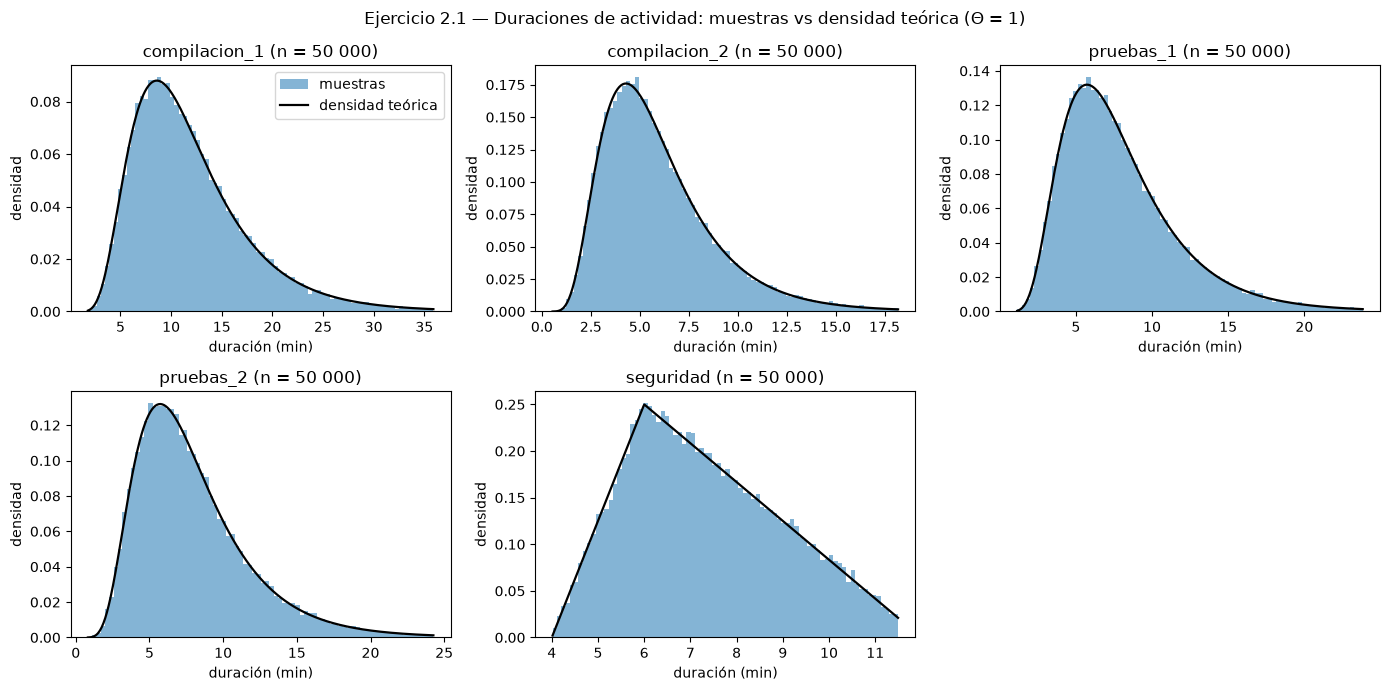

In [4]:
# Ejercicio 2.1 — Verificación de la conversión lognormal (y de la triangular de seguridad)
M_MUESTRAS = 50_000
rng_verif = np.random.default_rng(np.random.SeedSequence([SEMILLA_MAESTRA, 21]))

# (a) La conversión es exacta algebraicamente: E y DE recuperadas desde (mu, sigma)
for act, (m, s) in ACTIVIDADES_LOGNORMALES.items():
    mu, sig = parametros_lognormal(m, s)
    assert np.isclose(np.exp(mu + sig**2 / 2), m)
    assert np.isclose(np.sqrt(np.expm1(sig**2)) * m, s)

# (b) Validación de parámetros inválidos
for args in [(0, 1), (-5, 2), (10, -1), (np.nan, 1)]:
    try:
        parametros_lognormal(*args)
        raise AssertionError(f'Debió rechazar {args}')
    except ValueError:
        pass

# (c) Comparación empírica con 50 000 muestras por actividad
filas, muestras = [], {}
for act, (m, s) in ACTIVIDADES_LOGNORMALES.items():
    mu, sig = parametros_lognormal(m, s)
    x = rng_verif.lognormal(mu, sig, size=M_MUESTRAS)
    muestras[act] = (x, stats.lognorm(s=sig, scale=np.exp(mu)))
    filas.append({'actividad': act, 'distribucion': 'Lognormal', 'mu': mu, 'sigma': sig,
                  'media_teorica': m, 'media_empirica': x.mean(),
                  'z_media': (x.mean() - m) / (s / np.sqrt(M_MUESTRAS)),
                  'de_teorica': s, 'de_empirica': x.std(ddof=1)})

a_t, moda_t, b_t = SEGURIDAD_TRIANGULAR
dist_tri = stats.triang(c=(moda_t - a_t) / (b_t - a_t), loc=a_t, scale=b_t - a_t)
x = rng_verif.triangular(a_t, moda_t, b_t, size=M_MUESTRAS)
muestras['seguridad'] = (x, dist_tri)
filas.append({'actividad': 'seguridad', 'distribucion': 'Triangular(4,6,12)', 'mu': np.nan, 'sigma': np.nan,
              'media_teorica': dist_tri.mean(), 'media_empirica': x.mean(),
              'z_media': (x.mean() - dist_tri.mean()) / (dist_tri.std() / np.sqrt(M_MUESTRAS)),
              'de_teorica': dist_tri.std(), 'de_empirica': x.std(ddof=1)})

verif_dist = pd.DataFrame(filas).set_index('actividad')
verif_dist['error_rel_de_%'] = 100 * (verif_dist['de_empirica'] / verif_dist['de_teorica'] - 1)
assert (verif_dist['z_media'].abs() < 4).all()
assert (verif_dist['error_rel_de_%'].abs() < 5).all()
print(f'{M_MUESTRAS} muestras por actividad; tiempos en minutos. z_media = (media empírica - teórica) / error estándar.')
display(verif_dist.round(4))

# (d) Histogramas con la densidad teórica superpuesta
fig, ejes = plt.subplots(2, 3, figsize=(14, 7))
for ax, (act, (x, dist)) in zip(ejes.flat, muestras.items()):
    hasta = np.quantile(x, 0.995)
    ax.hist(x[x <= hasta], bins=80, density=True, alpha=0.55, label='muestras')
    malla = np.linspace(x.min(), hasta, 400)
    ax.plot(malla, dist.pdf(malla), 'k-', lw=1.6, label='densidad teórica')
    ax.set_title(f'{act} (n = {M_MUESTRAS:,})'.replace(',', ' '))
    ax.set_xlabel('duración (min)')
    ax.set_ylabel('densidad')
ejes.flat[0].legend()
ejes.flat[-1].axis('off')
fig.suptitle('Ejercicio 2.1 — Duraciones de actividad: muestras vs densidad teórica (Θ = 1)')
fig.tight_layout()
plt.show()

#### 2.3–2.4 Reproducibilidad, flujos separados y estructura de la jornada

In [5]:
# Ejercicio 2.3–2.4 — Reproducibilidad, flujos separados y estructura de la jornada
controles = []
def control(descripcion, condicion):
    assert condicion, descripcion
    controles.append({'control': descripcion, 'resultado': 'OK'})

j_a = generar_jornada(CONFIG_NOMINAL, SEMILLA_MAESTRA)
j_b = generar_jornada(CONFIG_NOMINAL, SEMILLA_MAESTRA)
pd.testing.assert_frame_equal(j_a, j_b)
control('Misma semilla → jornada idéntica (assert_frame_equal)', True)
control('Cada llamada devuelve un DataFrame nuevo (no comparte memoria)', j_a is not j_b)

ss = np.random.SeedSequence(SEMILLA_MAESTRA)
pd.testing.assert_frame_equal(generar_jornada(CONFIG_NOMINAL, ss), generar_jornada(CONFIG_NOMINAL, ss))
pd.testing.assert_frame_equal(generar_jornada(CONFIG_NOMINAL, ss), j_a)
control('Pasar SeedSequence equivale al entero y es repetible', True)

semillas_prueba = generar_semillas(300, bloque=5)
control('generar_semillas: 300 semillas distintas y reproducibles',
        len(set(semillas_prueba)) == 300 and semillas_prueba == generar_semillas(300, bloque=5))
control('Bloques experimentales distintos → listas de semillas distintas',
        set(generar_semillas(300, bloque=5)).isdisjoint(generar_semillas(300, bloque=8)))
huellas = {tuple(generar_jornada(CONFIG_NOMINAL, s)['llegada'].round(9).head(3)) for s in semillas_prueba[:100]}
control('100 repeticiones distintas → 100 secuencias de llegadas distintas', len(huellas) == 100)

# Los seis flujos deben ser estadísticamente independientes: los primeros uniformes no coinciden
flujos = crear_flujos(SEMILLA_MAESTRA)
primeros = {nombre: g.random(5) for nombre, g in flujos.items()}
control('Los seis flujos producen secuencias diferentes entre sí',
        len({tuple(v) for v in primeros.values()}) == len(FLUJOS))

# Aislamiento de flujos: cambiar un parámetro solo cambia lo que le corresponde
otras = ['id', 'llegada', 'tramo'] + DURACIONES + ['retrabajo']
j_ps = generar_jornada(replace(CONFIG_NOMINAL, p_seguridad=0.50), SEMILLA_MAESTRA)
pd.testing.assert_frame_equal(j_a[otras], j_ps[otras])
control('Cambiar p_s no altera llegadas, duraciones ni retrabajo', True)
control('Subir p_s solo agrega trabajos a la ruta de seguridad (acoplamiento monótono)',
        (j_ps['requiere_seguridad'] | ~j_a['requiere_seguridad']).all())

j_pf = generar_jornada(replace(CONFIG_NOMINAL, p_retrabajo=0.20), SEMILLA_MAESTRA)
control('Subir p_f solo agrega trabajos al retrabajo (acoplamiento monótono)',
        (j_pf['retrabajo'] | ~j_a['retrabajo']).all() and j_pf['llegada'].equals(j_a['llegada']))

j_theta = generar_jornada(replace(CONFIG_NOMINAL, lentitud=1.25), SEMILLA_MAESTRA)
np.testing.assert_allclose(j_theta[DURACIONES].to_numpy(), 1.25 * j_a[DURACIONES].to_numpy())
control('Θ = 1.25 multiplica una sola vez los mismos sorteos; llegadas y rutas iguales',
        j_theta['llegada'].equals(j_a['llegada']) and j_theta['retrabajo'].equals(j_a['retrabajo']))

j_vacia = generar_jornada(replace(CONFIG_NOMINAL, demanda=0.0), SEMILLA_MAESTRA)
control('Jornada sin llegadas: 0 filas con las mismas columnas y tipos',
        len(j_vacia) == 0 and list(j_vacia.columns) == list(COLUMNAS_JORNADA)
        and (j_vacia.dtypes.astype(str) == pd.Series(COLUMNAS_JORNADA)).all())

# Estructura de una jornada: rangos, orden y coherencia del tramo
cortes = TRAMOS_LLEGADAS['inicio'].to_numpy()
control('Columnas mínimas presentes y con los tipos declarados',
        (j_a.dtypes.astype(str) == pd.Series(COLUMNAS_JORNADA)).all())
control('Llegadas en (0, 480), ordenadas, sin trabajo automático en t = 0',
        j_a['llegada'].between(0, 480, inclusive='neither').all() and j_a['llegada'].is_monotonic_increasing)
control('ids consecutivos 0..N-1 en orden de llegada', (j_a['id'].to_numpy() == np.arange(len(j_a))).all())
control('Cada llegada cae dentro de su tramo',
        (np.searchsorted(cortes, j_a['llegada'].to_numpy(), side='right') - 1 == j_a['tramo'].to_numpy()).all())
control('Todas las duraciones (incluida la 2.ª visita) existen y son > 0',
        j_a[DURACIONES].notna().all().all() and (j_a[DURACIONES] > 0).all().all())

display(pd.DataFrame(controles))
print(f'Jornada de referencia (semilla {SEMILLA_MAESTRA}): llegadas por tramo =',
      np.bincount(j_a['tramo'], minlength=len(TRAMOS_LLEGADAS)).tolist())

,control,resultado
0,Misma semilla → jornada idéntica (assert_frame...,OK
1,Cada llamada devuelve un DataFrame nuevo (no c...,OK
2,Pasar SeedSequence equivale al entero y es rep...,OK
3,generar_semillas: 300 semillas distintas y rep...,OK
4,Bloques experimentales distintos → listas de s...,OK
5,100 repeticiones distintas → 100 secuencias de...,OK
6,Los seis flujos producen secuencias diferentes...,OK
7,"Cambiar p_s no altera llegadas, duraciones ni ...",OK
8,Subir p_s solo agrega trabajos a la ruta de se...,OK
9,Subir p_f solo agrega trabajos al retrabajo (a...,OK


Jornada de referencia (semilla 20261001): llegadas por tramo = [12, 28, 17, 15]


#### 2.5 Verificación estadística de llegadas por tramo y de las rutas

2000 jornadas nominales generadas en 6.1 s (semillas: bloque 2).
Llegadas por tramo, 2000 jornadas (trabajos por jornada). Poisson ⇒ varianza ≈ media.


,esperado λΔ,media_obs,IC95_inf,IC95_sup,z_media,varianza_obs,indice_dispersion
tramo,,,,,,,
"[0, 120)",14.4,14.256,14.084,14.427,-1.655,15.246,1.069
"[120, 240)",30.0,30.073,29.833,30.313,0.596,29.987,0.997
"[240, 360)",21.6,21.884,21.680,22.089,2.724,21.809,0.997
"[360, 480)",12.0,12.104,11.952,12.256,1.340,12.054,0.996
"Jornada [0, 480)",78.0,78.317,77.924,78.710,1.581,80.401,1.027


¿El valor teórico cae en el IC 95 %? {'[0, 120)': True, '[120, 240)': True, '[240, 360)': False, '[360, 480)': True, 'Jornada [0, 480)': True}


,n_llegadas,KS_estadistico,KS_p_valor
tramo,,,
"[0, 120)",28511,0.0042,0.6926
"[120, 240)",60146,0.0029,0.6870
"[240, 360)",43769,0.0036,0.6217
"[360, 480)",24208,0.0108,0.0071


Réplica independiente con 10000 jornadas (semillas: bloque 3)


...

Proporción de rutas sobre 156634 trabajos de 2000 jornadas


,p_teorica,p_observada,Wilson95_inf,Wilson95_sup,z
ruta,,,,,
retrabajo,0.12,0.1186,0.1170,0.1202,-1.7190
requiere_seguridad,0.30,0.3007,0.2984,0.3030,0.5834


Independencia retrabajo × seguridad: χ² = 0.657, p-valor = 0.418


requiere_seguridad,False,True
retrabajo,,
False,96500,41559
True,13038,5537


D = 1.5, 500 jornadas: media de llegadas = 116.43 (IC95 115.48–117.38); teórico = 117.0


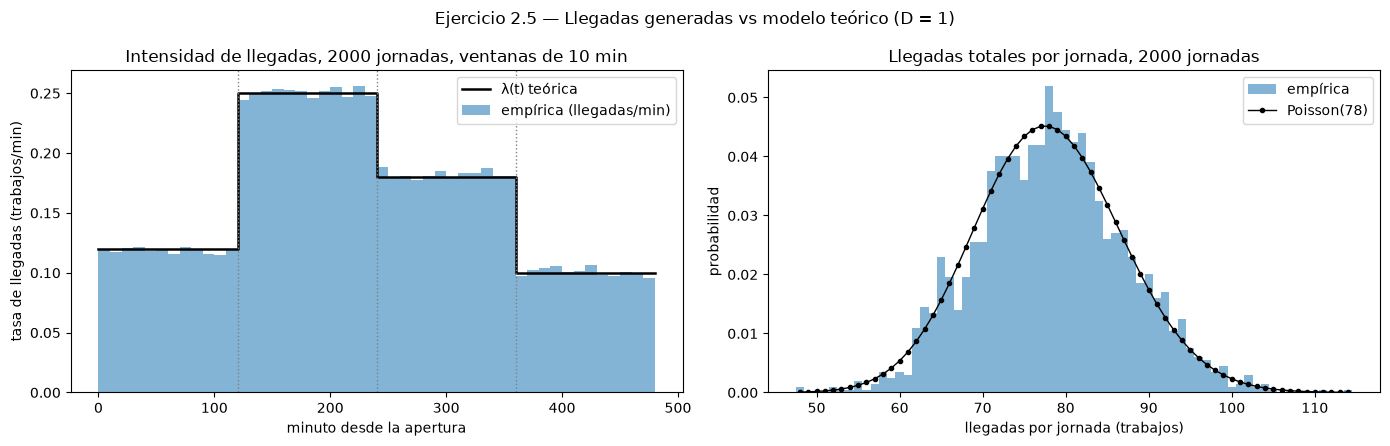

In [6]:
# Ejercicio 2.5 — Verificación estadística de llegadas por tramo y proporciones de rutas
R_VERIF = 2_000
semillas_verif = generar_semillas(R_VERIF, bloque=2)
t0 = perf_counter()
jornadas_verif = [generar_jornada(CONFIG_NOMINAL, s) for s in semillas_verif]
print(f'{R_VERIF} jornadas nominales generadas en {perf_counter() - t0:.1f} s (semillas: bloque 2).')

# (a) Llegadas por tramo: la unidad es la jornada (un conteo por tramo y día)
k_tramos = len(TRAMOS_LLEGADAS)
conteos = np.array([np.bincount(j['tramo'], minlength=k_tramos) for j in jornadas_verif])
esperado = (TRAMOS_LLEGADAS['tasa_nominal'] * (TRAMOS_LLEGADAS['fin'] - TRAMOS_LLEGADAS['inicio'])).to_numpy()
t_crit = stats.t.ppf(0.975, R_VERIF - 1)
filas = []
for k in range(k_tramos):
    c = conteos[:, k]
    ee = c.std(ddof=1) / np.sqrt(R_VERIF)
    filas.append({'tramo': f"[{TRAMOS_LLEGADAS['inicio'][k]:.0f}, {TRAMOS_LLEGADAS['fin'][k]:.0f})",
                  'esperado λΔ': esperado[k], 'media_obs': c.mean(),
                  'IC95_inf': c.mean() - t_crit * ee, 'IC95_sup': c.mean() + t_crit * ee,
                  'z_media': (c.mean() - esperado[k]) / ee,
                  'varianza_obs': c.var(ddof=1), 'indice_dispersion': c.var(ddof=1) / c.mean()})
total = conteos.sum(axis=1)
ee = total.std(ddof=1) / np.sqrt(R_VERIF)
filas.append({'tramo': 'Jornada [0, 480)', 'esperado λΔ': esperado.sum(), 'media_obs': total.mean(),
              'IC95_inf': total.mean() - t_crit * ee, 'IC95_sup': total.mean() + t_crit * ee,
              'z_media': (total.mean() - esperado.sum()) / ee,
              'varianza_obs': total.var(ddof=1), 'indice_dispersion': total.var(ddof=1) / total.mean()})
verif_llegadas = pd.DataFrame(filas).set_index('tramo')
print(f'Llegadas por tramo, {R_VERIF} jornadas (trabajos por jornada). Poisson ⇒ varianza ≈ media.')
display(verif_llegadas.round(3))
dentro = (verif_llegadas['IC95_inf'] <= verif_llegadas['esperado λΔ']) & (verif_llegadas['esperado λΔ'] <= verif_llegadas['IC95_sup'])
print('¿El valor teórico cae en el IC 95 %?', dentro.to_dict())
assert (abs(verif_llegadas['media_obs'] / verif_llegadas['esperado λΔ'] - 1) < 0.02).all()
assert verif_llegadas['indice_dispersion'].between(0.9, 1.1).all()

# (b) Dentro de cada tramo, las llegadas deben ser uniformes (KS contra U(a, b))
todas = pd.concat(jornadas_verif, ignore_index=True)
filas = []
for k, t in enumerate(TRAMOS_LLEGADAS.itertuples(index=False)):
    x = todas.loc[todas['tramo'] == k, 'llegada']
    ks = stats.kstest(x, stats.uniform(loc=t.inicio, scale=t.fin - t.inicio).cdf)
    filas.append({'tramo': f'[{t.inicio:.0f}, {t.fin:.0f})', 'n_llegadas': len(x),
                  'KS_estadistico': ks.statistic, 'KS_p_valor': ks.pvalue})
display(pd.DataFrame(filas).set_index('tramo').round(4))

# (b2) Réplica independiente: con ~10 pruebas simultáneas es esperable que alguna salga "rara"
#      por azar. Repetimos con 10 000 jornadas de otro bloque de semillas antes de concluir nada.
R_REPLICA = 10_000
replica = [generar_jornada(CONFIG_NOMINAL, s)[['tramo', 'llegada']] for s in generar_semillas(R_REPLICA, bloque=3)]
conteos_rep = np.array([np.bincount(j['tramo'], minlength=k_tramos) for j in replica])
todas_rep = pd.concat(replica, ignore_index=True)
filas = []
for k, t in enumerate(TRAMOS_LLEGADAS.itertuples(index=False)):
    c = conteos_rep[:, k]
    x = todas_rep.loc[todas_rep['tramo'] == k, 'llegada']
    filas.append({'tramo': f'[{t.inicio:.0f}, {t.fin:.0f})', 'esperado λΔ': esperado[k], 'media_obs': c.mean(),
                  'z_media': (c.mean() - esperado[k]) / (c.std(ddof=1) / np.sqrt(R_REPLICA)),
                  'indice_dispersion': c.var(ddof=1) / c.mean(),
                  'KS_p_valor': stats.kstest(x, stats.uniform(loc=t.inicio, scale=t.fin - t.inicio).cdf).pvalue})
verif_replica = pd.DataFrame(filas).set_index('tramo')
print(f'Réplica independiente con {R_REPLICA} jornadas (semillas: bloque 3)')
display(verif_replica.round(4))

# (b3) Si el generador es correcto, los p-valores de réplicas independientes deben ser ~U(0, 1).
#      20 réplicas × 2 000 jornadas. Se usa solo el flujo de llegadas, que es el mismo que usa
#      generar_jornada (las llegadas se sortean primero y en su propio flujo).
N_REPLICAS, R_POR_REPLICA = 20, 2_000
p_ks = {k: [] for k in range(k_tramos)}
for b in range(N_REPLICAS):
    tiempos, etiquetas = zip(*(generar_llegadas(crear_flujos(s)['llegadas'], CONFIG_NOMINAL.demanda)
                               for s in generar_semillas(R_POR_REPLICA, bloque=100 + b)))
    tiempos, etiquetas = np.concatenate(tiempos), np.concatenate(etiquetas)
    for k, t in enumerate(TRAMOS_LLEGADAS.itertuples(index=False)):
        p_ks[k].append(stats.kstest(tiempos[etiquetas == k],
                                    stats.uniform(loc=t.inicio, scale=t.fin - t.inicio).cdf).pvalue)
resumen_p = pd.DataFrame({
    f'[{t.inicio:.0f}, {t.fin:.0f})': {'p_KS_min': min(p_ks[k]), 'p_KS_mediana': np.median(p_ks[k]),
                                       'réplicas con p<0.05': sum(p < 0.05 for p in p_ks[k]),
                                       'KS de los p-valores vs U(0,1), p': stats.kstest(p_ks[k], 'uniform').pvalue}
    for k, t in enumerate(TRAMOS_LLEGADAS.itertuples(index=False))}).T
print(f'Uniformidad dentro de cada tramo en {N_REPLICAS} réplicas de {R_POR_REPLICA} jornadas (bloques 100–119)')
display(resumen_p.round(3))

# (c) Proporciones de rutas. Las rutas se sortean i.i.d. por trabajo, así que aquí sí se puede
#     agregar a nivel de trabajo (a diferencia de las métricas de cola, que dependen entre sí).
n_trab = len(todas)
filas = []
for col, p in [('retrabajo', CONFIG_NOMINAL.p_retrabajo), ('requiere_seguridad', CONFIG_NOMINAL.p_seguridad)]:
    k = int(todas[col].sum())
    li, ls = intervalo_wilson(k, n_trab)
    filas.append({'ruta': col, 'p_teorica': p, 'p_observada': k / n_trab, 'Wilson95_inf': li,
                  'Wilson95_sup': ls, 'z': (k / n_trab - p) / np.sqrt(p * (1 - p) / n_trab)})
verif_rutas = pd.DataFrame(filas).set_index('ruta')
print(f'Proporción de rutas sobre {n_trab} trabajos de {R_VERIF} jornadas')
display(verif_rutas.round(4))
assert (verif_rutas['z'].abs() < 4).all()

tabla_cruzada = pd.crosstab(todas['retrabajo'], todas['requiere_seguridad'])
chi2, p_indep, _, _ = stats.chi2_contingency(tabla_cruzada)
print(f'Independencia retrabajo × seguridad: χ² = {chi2:.3f}, p-valor = {p_indep:.3f}')
display(tabla_cruzada)

# (d) config.demanda escala las tasas: con D = 1.5 se esperan 1.5 × 78 = 117 llegadas
R_D = 500
n_d15 = np.array([len(generar_jornada(replace(CONFIG_NOMINAL, demanda=1.5), s))
                  for s in generar_semillas(R_D, bloque=22)])
ee = n_d15.std(ddof=1) / np.sqrt(R_D)
print(f'D = 1.5, {R_D} jornadas: media de llegadas = {n_d15.mean():.2f} '
      f'(IC95 {n_d15.mean() - 1.96 * ee:.2f}–{n_d15.mean() + 1.96 * ee:.2f}); teórico = {1.5 * esperado.sum():.1f}')

# (e) Gráficas: intensidad empírica de llegadas vs λ(t), y distribución de N vs Poisson(78)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4.5))
ancho = 10
bordes = np.arange(0, 481, ancho)
frec, _ = np.histogram(todas['llegada'], bins=bordes)
ax1.bar(bordes[:-1], frec / (R_VERIF * ancho), width=ancho, align='edge', alpha=0.55,
        label='empírica (llegadas/min)')
ax1.step(np.r_[TRAMOS_LLEGADAS['inicio'], 480], np.r_[TRAMOS_LLEGADAS['tasa_nominal'], 0.10],
         where='post', color='k', lw=1.8, label='λ(t) teórica')
for corte in TRAMOS_LLEGADAS['inicio'][1:]:
    ax1.axvline(corte, color='grey', ls=':', lw=1)
ax1.set(xlabel='minuto desde la apertura', ylabel='tasa de llegadas (trabajos/min)',
        title=f'Intensidad de llegadas, {R_VERIF} jornadas, ventanas de {ancho} min')
ax1.legend()

valores = np.arange(total.min(), total.max() + 1)
ax2.hist(total, bins=np.arange(total.min() - 0.5, total.max() + 1.5), density=True, alpha=0.55,
         label='empírica')
ax2.plot(valores, stats.poisson(esperado.sum()).pmf(valores), 'k.-', lw=1, label='Poisson(78)')
ax2.set(xlabel='llegadas por jornada (trabajos)', ylabel='probabilidad',
        title=f'Llegadas totales por jornada, {R_VERIF} jornadas')
ax2.legend()
fig.suptitle('Ejercicio 2.5 — Llegadas generadas vs modelo teórico (D = 1)')
fig.tight_layout()
plt.show()

### Resultados e interpretación del ejercicio 2

- **Lognormal:** $\sigma^2=\ln(1+s^2/m^2)$ y $\mu=\ln m-\sigma^2/2$. Con 50 000 muestras por actividad, las medias y desviaciones coinciden con las teóricas ($|z|<1.6$ en la media; error menor al 1.2 % en la desviación). Pasar 12 y 6 directamente a `rng.lognormal` daría una media de unos $10^{13}$ minutos.
- **Llegadas por tramos:** en cada tramo se sortea $N\sim\text{Poisson}(D\lambda\cdot120)$ y luego $N$ tiempos uniformes ordenados. Es exacto porque, dado $N$, los tiempos de un proceso Poisson son uniformes y los tramos son independientes; así ninguna llegada usa la tasa de otro tramo. No hay una llegada forzada en $t=0$.
- **Parámetros:** $D$ solo escala las tasas; $\Theta$ multiplica una sola vez las duraciones ya sorteadas; las rutas se deciden con $U<p$, así que subir $p$ solo agrega trabajos a la ruta.
- **Semillas:** 6 flujos independientes creados con `SeedSequence`: llegadas, compilación, pruebas, seguridad y las dos rutas. Los 17 controles pasan: la misma semilla reproduce la jornada y semillas distintas dan jornadas distintas.
- **Verificación (2 000 jornadas):** las medias por tramo quedan a menos del 1.3 % de $\lambda\Delta$ y la varianza ≈ media, como en un Poisson. Retrabajo: 11.9 % (IC 95 %: 11.7–12.0 %); seguridad: 30.1 % (IC 95 %: 29.8–30.3 %). Un tramo quedó fuera de su IC 95 %, algo esperable por azar con tantas pruebas; la réplica con 10 000 jornadas lo confirma ($|z|<1.5$ en todos los tramos).
- **Mismas entradas entre políticas:** la jornada se genera una sola vez y se pasa igual a P0–P4. El DES lee las duraciones por `id` y nunca sortea, así que las diferencias entre políticas se deben solo a la capacidad.

## Ejercicio 3 — Implementación del DES completo · 18 puntos

Implementen el recorrido con **SimPy**, separando la configuración, las entradas por entidad, la lógica del modelo y la ejecución de experimentos, como en las clases 8 y 14. La interfaz pública será `simular_jornada(politica, jornada, config)`.

La función debe devolver un diccionario con:

- `trabajos`: `DataFrame` con las entradas y los tiempos de entrada a cola, inicio y fin de **cada visita**, llegada y salida final.
- `eventos`: registro con `tiempo`, `orden`, `id`, `evento`, `recurso` e `intento`. Incluyan entrada a cola, inicio de servicio, fin de servicio y salida. `orden` permite reproducir empates.
- `resumen`: métricas diarias descritas en la especificación, más número de llegadas y número total de salidas de la cohorte.

**Requisitos de implementación:**

1. Recursos compartidos de las capacidades indicadas; solicitudes FIFO y liberación al terminar cada actividad.
2. Ruta con hasta dos visitas a compilación y pruebas, y a lo sumo una a seguridad.
3. Uso de las entradas precalculadas: el DES no debe volver a sortear duraciones ni decidir rutas según la política.
4. Cierre de llegadas y vaciado completo, sin avanzar el reloj minuto a minuto. No terminen el modelo dejando trabajos sin completar.
5. Estados distinguibles para trabajos esperando, en servicio y completados. Las etapas no visitadas deben conservar tiempos `NaN`, no esperas ficticias iguales a cero.
6. Cálculo de utilización a partir de intervalos ocupados o integración del número de servidores ocupados. No promedien observaciones de ocupación separadas por tiempos desiguales sin ponderarlas.
7. No modifiquen el `DataFrame` de entradas compartido al ejecutar una política.

**Evidencia:** implementación documentada, traza de al menos tres trabajos con rutas distintas y una trayectoria de colas/ocupación. Pueden reconstruir la trayectoria con el registro de eventos; el muestreo cada minuto para una gráfica no debe convertirse en el motor de simulación.

Resumen P0 demo: {'n_llegadas': 72, 'n_salidas': 72, 'N': 72, 'W_mean': 26.74, 'W_p90': 47.312, 'T_mean': 56.585, 'T_p95': 104.068, 'sla': 0.278, 'p_retraso_60': 0.472, 'p_riesgo_90': 0.056, 'indicador_R': 0, 'throughput': 7.75, 'backlog': 10, 'util_comp': 0.864, 'util_prue': 0.629, 'util_seg': 0.311, 'n_retrabajos': 9, 'V': 63.115, 't_max_salida': 543.115, 'politica': 'P0'}
Eventos: 708 | columnas: ['tiempo', 'orden', 'id', 'evento', 'recurso', 'intento']
Traza de 3 trabajos (directo / con retrabajo / con seguridad):


'    tiempo  orden  id          evento     recurso intento\n  0.873837      1   0         llegada           -       -\n  0.873837      2   0    entrada_cola compilacion       1\n  0.873837      3   0 inicio_servicio compilacion       1\n 11.123614     10   0    fin_servicio compilacion       1\n 11.123614     11   0    entrada_cola     pruebas       1\n 11.123614     12   0 inicio_servicio     pruebas       1\n 27.899678     32   0    fin_servicio     pruebas       1\n 27.899678     33   0    entrada_cola   seguridad       1\n 27.899678     34   0 inicio_servicio   seguridad       1\n 37.199471     45   0    fin_servicio   seguridad       1\n 37.199471     46   0          salida           -       -\n 13.994713     13   2         llegada           -       -\n 13.994713     14   2    entrada_cola compilacion       1\n 13.994713     15   2 inicio_servicio compilacion       1\n 17.958469     16   2    fin_servicio compilacion       1\n 17.958469     17   2    entrada_cola     pruebas      

,0,2,7
id,0,2,7
llegada,0.873837,13.994713,50.570124
retrabajo,False,False,True
requiere_seguridad,True,False,True
espera_comp_1,0.0,0.0,0.0
espera_pruebas_1,0.0,2.476562,0.0
espera_comp_2,NaN,NaN,1.667917
espera_pruebas_2,NaN,NaN,0.0
espera_seg,0.0,NaN,0.0
inicio_comp_1,0.873837,13.994713,50.570124


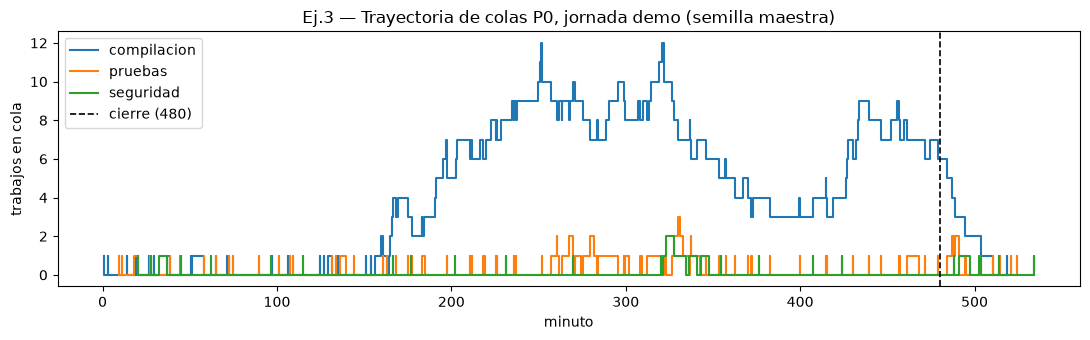

In [7]:
# Ejercicio 3 — DES completo con SimPy (interfaz según enunciado)
# Retorna dict(trabajos, eventos, resumen).
# eventos: tiempo, orden, id, evento, recurso, intento.
# eventos válidos: llegada | entrada_cola | inicio_servicio | fin_servicio | salida.
# recurso: '-' | compilacion | pruebas | seguridad. intento: 1 | 2 | '-'.

import simpy


def simular_jornada(politica, jornada, config):
    """Simula la cohorte completa de una jornada con la capacidad indicada.

    - Usa SOLO las entradas precalculadas (duraciones con Theta aplicado,
      banderas retrabajo/requiere_seguridad); no sortea nada.
    - Recursos FIFO que se liberan al terminar cada actividad.
    - Cierre: las llegadas son las filas de `jornada` (< 480); el reloj avanza
      por eventos hasta completar TODOS los trabajos (vaciado incluido).
    - `orden` es un secuencial de registro: reproduce el orden de SimPy ante
      empates de tiempo y hace la traza reproducible.
    - No modifica el DataFrame `jornada` recibido.
    """
    H = float(config.horizonte)
    jor = jornada.sort_values('llegada').reset_index(drop=True).copy() if len(jornada) else jornada.copy()
    env = simpy.Environment()
    r_comp = simpy.Resource(env, capacity=int(politica.n_compilacion))
    r_prue = simpy.Resource(env, capacity=int(politica.n_pruebas))
    r_seg = simpy.Resource(env, capacity=int(politica.n_seguridad))

    ocupado = {'compilacion': [], 'pruebas': [], 'seguridad': []}
    eventos = []
    orden = [0]

    def registrar(tiempo, jid, evento, recurso, intento):
        orden[0] += 1
        eventos.append({'tiempo': float(tiempo), 'orden': orden[0], 'id': jid,
                        'evento': evento, 'recurso': recurso, 'intento': intento})

    resultados = {}

    def atender(jid, recurso_nombre, recurso, duracion, intento):
        registrar(env.now, jid, 'entrada_cola', recurso_nombre, intento)
        t_cola = env.now
        req = recurso.request()
        yield req
        espera = env.now - t_cola
        registrar(env.now, jid, 'inicio_servicio', recurso_nombre, intento)
        t_ini = env.now
        yield env.timeout(float(duracion))
        t_fin = env.now
        recurso.release(req)
        registrar(t_fin, jid, 'fin_servicio', recurso_nombre, intento)
        ocupado[recurso_nombre].append((t_ini, t_fin))
        return espera, t_ini, t_fin

    def proceso(fila):
        jid = int(fila['id'])
        t_lleg = float(fila['llegada'])
        yield env.timeout(max(0.0, t_lleg - env.now))
        registrar(env.now, jid, 'llegada', '-', '-')
        t0 = env.now
        esp_c1, ini_c1, fin_c1 = yield from atender(jid, 'compilacion', r_comp, float(fila['compilacion_1']), 1)
        W = ini_c1 - t0
        esp_p1, ini_p1, fin_p1 = yield from atender(jid, 'pruebas', r_prue, float(fila['pruebas_1']), 1)
        esp_c2, ini_c2, fin_c2 = np.nan, np.nan, np.nan
        esp_p2, ini_p2, fin_p2 = np.nan, np.nan, np.nan
        t_aprueba = fin_p1
        if bool(fila['retrabajo']):
            esp_c2, ini_c2, fin_c2 = yield from atender(jid, 'compilacion', r_comp, float(fila['compilacion_2']), 2)
            esp_p2, ini_p2, fin_p2 = yield from atender(jid, 'pruebas', r_prue, float(fila['pruebas_2']), 2)
            t_aprueba = fin_p2
        esp_s, ini_s, fin_s = np.nan, np.nan, np.nan
        if bool(fila['requiere_seguridad']):
            esp_s, ini_s, fin_s = yield from atender(jid, 'seguridad', r_seg, float(fila['seguridad']), 1)
            t_sal = fin_s
        else:
            t_sal = t_aprueba
        T = t_sal - t0
        registrar(t_sal, jid, 'salida', '-', '-')
        resultados[jid] = dict(
            id=jid, llegada=t0, retrabajo=bool(fila['retrabajo']),
            requiere_seguridad=bool(fila['requiere_seguridad']),
            espera_comp_1=esp_c1, espera_pruebas_1=esp_p1,
            espera_comp_2=esp_c2, espera_pruebas_2=esp_p2, espera_seg=esp_s,
            inicio_comp_1=ini_c1, fin_comp_1=fin_c1,
            inicio_pruebas_1=ini_p1, fin_pruebas_1=fin_p1,
            inicio_comp_2=ini_c2, fin_comp_2=fin_c2,
            inicio_pruebas_2=ini_p2, fin_pruebas_2=fin_p2,
            inicio_seg=ini_s, fin_seg=fin_s,
            W=W, T=T, t_salida=t_sal,
            cumple_SLA=bool(W < 10), retrasado_60=bool(T > 60),
            riesgo_90=bool(T > 90))

    for _, fila in jor.iterrows():
        env.process(proceso(fila))
    env.run()

    cols_trab = ['id', 'llegada', 'retrabajo', 'requiere_seguridad',
                 'espera_comp_1', 'espera_pruebas_1', 'espera_comp_2', 'espera_pruebas_2',
                 'espera_seg', 'inicio_comp_1', 'fin_comp_1', 'inicio_pruebas_1',
                 'fin_pruebas_1', 'inicio_comp_2', 'fin_comp_2', 'inicio_pruebas_2',
                 'fin_pruebas_2', 'inicio_seg', 'fin_seg', 'W', 'T', 't_salida',
                 'cumple_SLA', 'retrasado_60', 'riesgo_90']
    if resultados:
        trabajos = pd.DataFrame([resultados[k] for k in sorted(resultados)])[cols_trab]
        trabajos = trabajos.sort_values('id').reset_index(drop=True)
    else:
        trabajos = pd.DataFrame(columns=cols_trab)
    df_eventos = (pd.DataFrame(eventos, columns=['tiempo', 'orden', 'id', 'evento', 'recurso', 'intento'])
                  .sort_values(['tiempo', 'orden']).reset_index(drop=True))

    n_lleg = int(len(jor))
    n_sal = int(len(trabajos))
    if n_sal == 0:
        resumen = dict(n_llegadas=0, n_salidas=0, N=0, W_mean=np.nan, W_p90=np.nan,
                       T_mean=np.nan, T_p95=np.nan, sla=np.nan, p_retraso_60=np.nan,
                       p_riesgo_90=0.0, indicador_R=0, throughput=0.0, backlog=0,
                       util_comp=0.0, util_prue=0.0, util_seg=0.0,
                       n_retrabajos=0, V=0.0, t_max_salida=np.nan)
    else:
        Wv = trabajos['W'].to_numpy()
        Tv = trabajos['T'].to_numpy()
        sal = trabajos['t_salida'].to_numpy()
        thr = float(np.sum(sal <= H) / (H / 60.0))
        backlog = int(np.sum(sal > H))
        V = float(max(0.0, sal.max() - H))

        def util(lista, cap):
            tot = sum(max(0.0, min(b, H) - min(max(a, 0.0), H)) for a, b in lista)
            return tot / (H * cap) if cap > 0 else np.nan

        resumen = dict(
            n_llegadas=n_lleg, n_salidas=n_sal, N=n_sal,
            W_mean=float(Wv.mean()), W_p90=float(np.quantile(Wv, 0.9)),
            T_mean=float(Tv.mean()), T_p95=float(np.quantile(Tv, 0.95)),
            sla=float(trabajos['cumple_SLA'].mean()),
            p_retraso_60=float(trabajos['retrasado_60'].mean()),
            p_riesgo_90=float(trabajos['riesgo_90'].mean()),
            indicador_R=int(float(trabajos['riesgo_90'].mean()) > 0.20),
            throughput=float(thr), backlog=int(backlog),
            util_comp=float(util(ocupado['compilacion'], politica.n_compilacion)),
            util_prue=float(util(ocupado['pruebas'], politica.n_pruebas)),
            util_seg=float(util(ocupado['seguridad'], politica.n_seguridad)),
            n_retrabajos=int(trabajos['retrabajo'].sum()), V=float(V),
            t_max_salida=float(sal.max()))
    resumen['politica'] = politica.nombre
    return {'trabajos': trabajos, 'eventos': df_eventos, 'resumen': resumen, 'ocupado': ocupado}


def trayectoria_colas(eventos, recursos=('compilacion', 'pruebas', 'seguridad')):
    """Reconstruye la longitud de cola por recurso desde el registro de eventos.

    qlen sube en 1 con 'entrada_cola' y baja en 1 con 'inicio_servicio'.
    Retorna DataFrame(t, recurso, qlen) escalonado, apto para step plot.
    """
    filas = []
    for rec in recursos:
        q = 0
        sub = eventos[eventos['recurso'] == rec].sort_values(['tiempo', 'orden'])
        for r in sub.itertuples(index=False):
            if r.evento == 'entrada_cola':
                q += 1
            elif r.evento == 'inicio_servicio':
                q -= 1
            else:
                continue
            filas.append((r.tiempo, rec, q))
    return pd.DataFrame(filas, columns=['t', 'recurso', 'qlen'])


# --- Demo Ej.3: traza de 3 trabajos con rutas distintas + trayectoria de colas (P0 nominal) ---
jornada_demo = generar_jornada(CONFIG_NOMINAL, seed=SEMILLA_MAESTRA)
res_demo = simular_jornada(POLITICAS["P0"], jornada_demo, CONFIG_NOMINAL)
print('Resumen P0 demo:', {k: (round(v, 3) if isinstance(v, float) else v) for k, v in res_demo["resumen"].items()})
tr = res_demo["trabajos"]
ev = res_demo["eventos"]
print('Eventos:', len(ev), '| columnas:', list(ev.columns))
traza3_ids = [tr.loc[~tr["retrabajo"] & ~tr["requiere_seguridad"]].iloc[0]["id"],
              tr.loc[tr["retrabajo"]].iloc[0]["id"],
              tr.loc[tr["requiere_seguridad"]].iloc[0]["id"]]
print('Traza de 3 trabajos (directo / con retrabajo / con seguridad):')
display(ev[ev["id"].isin(traza3_ids)].sort_values(["id", "tiempo", "orden"]).to_string(index=False))
display(tr[tr["id"].isin(traza3_ids)].T)
tray = trayectoria_colas(ev)
fig, ax = plt.subplots(figsize=(11, 3.5))
for rec, g in tray.groupby("recurso"):
    ax.step(g["t"], g["qlen"], where="post", label=rec)
ax.axvline(480, color="k", ls="--", lw=1.2, label="cierre (480)")
ax.set(xlabel="minuto", ylabel="trabajos en cola", title="Ej.3 — Trayectoria de colas P0, jornada demo (semilla maestra)")
ax.legend(); fig.tight_layout(); plt.show()


### Resultados e interpretación del ejercicio 3

**Traza (jornada demo P0, semilla maestra, 72 trabajos).** Se muestran 3 trabajos con rutas
distintas: uno directo (compilación→pruebas→salida), uno con retrabajo (dos visitas a
compilación y pruebas) y uno con seguridad (visita única post-aprobación). En el registro
cada visita genera `entrada_cola → inicio_servicio → fin_servicio`; más `llegada` y `salida`
por trabajo. La columna `orden` es un secuencial de registro que reproduce el orden de
programación de SimPy ante empates y hace la corrida reproducible.

**Liberación de recursos.** Cada etapa solicita su recurso y lo libera al terminar
(`release` tras `timeout`); ningún trabajo retiene compilación mientras espera pruebas.
La espera de cada visita se mide como `inicio_servicio − entrada_cola` y `W_j` como
`inicio primera compilación − llegada`, de modo que las esperas emergen de la cola y no se
sortean.

**Segundas visitas.** Solo existen si `retrabajo=True` (sorteado antes del DES); sus tiempos
de espera/inicio/fin quedan en `NaN` en caso contrario, nunca en cero. La seguridad se
atiende una sola vez y siempre después de aprobar pruebas (`inicio_seg ≥ fin pruebas`).

**Métricas al cierre.** Resumen demo P0: `W` media 26.7 min, SLA 27.8%, `T` media 56.6 min,
throughput 7.75 trab/h (salidas ≤ 480), backlog 10, vaciado `V=63.1` min y utilizaciones
(comp 0.86, pruebas 0.63, seguridad 0.31) calculadas con el tiempo ocupado recortado a
`[0,480]`. La trayectoria de colas (gráfica) muestra congestión de compilación que persiste
tras el pico y se drena después del cierre; pruebas y seguridad drenan más rápido.


## Ejercicio 4 — Verificación y validación crítica · 10 puntos

Construyan pruebas automáticas relevantes. Diferencien **verificar que implementaron la especificación** de **validar que esa especificación representa una plataforma real**.

**A. Microcaso determinista.** Usen un agente de compilación y un ejecutor de pruebas. Los cuatro trabajos siguientes no tienen retrabajo ni seguridad:

| id | llegada, min | compilación inicial, min | primeras pruebas, min |
|---|---:|---:|---:|
| 0 | 0 | 4 | 3 |
| 1 | 1 | 2 | 1 |
| 2 | 2 | 1 | 2 |
| 3 | 3 | 3 | 1 |

Construyan a mano una tabla de inicios, finales, esperas y salidas. Compárenla con el simulador usando `assert` y una tolerancia numérica. Que este microcaso contenga una llegada en cero no cambia la regla del generador estocástico.

**B. Casos límite y conservación.** Verifiquen al menos:

- Ninguna llegada: cero salidas, backlog y vaciado; métricas por trabajo `NaN` y costo de capacidad de la jornada completa.
- Un trabajo que recorre retrabajo y seguridad: exactamente dos compilaciones, dos pruebas y un análisis; su tiempo total es la suma de sus cinco servicios al no existir competencia.
- Un trabajo que llega en el minuto 479 y cuya actividad cruza el cierre: recorte de utilización, inclusión en el backlog y exclusión del throughput operativo si sale después de 480.
- En toda observación de estado: llegadas acumuladas = trabajos esperando + trabajos en servicio + trabajos completados. Ocupación entre cero y capacidad; tiempos y esperas no negativos.
- Al finalizar: llegaron tantos trabajos como salieron y el sistema queda vacío. Ningún trabajo aparece en dos servicios simultáneamente.

**C. Validez del modelo.** Propongan tres comprobaciones que harían con datos de una plataforma real, incluyendo dependencia entre etapas o entre llegadas. Expliquen qué supuesto del modelo revisarían si esas comprobaciones fallan.

**Evidencia:** tabla manual, pruebas ejecutadas y reflexión sobre qué pueden y qué no pueden demostrar.

In [8]:
MICROCASO = pd.DataFrame({
    'id': [0, 1, 2, 3],
    'llegada': [0.0, 1.0, 2.0, 3.0],
    'compilacion_1': [4.0, 2.0, 1.0, 3.0],
    'pruebas_1': [3.0, 1.0, 2.0, 1.0],
    'compilacion_2': [0.0] * 4,
    'pruebas_2': [0.0] * 4,
    'seguridad': [0.0] * 4,
    'requiere_seguridad': [False] * 4,
    'retrabajo': [False] * 4,
})
POLITICA_MICROCASO = Politica('microcaso', 1, 1, 1)

# Completen la tabla manual, ejecuten el microcaso y añadan los casos límite.
# Los ceros en duraciones NO visitadas de estos datos de prueba son válidos;
# los tiempos de etapas no visitadas en las SALIDAS deben ser NaN.

# Ejercicio 4 — Batería de verificación (requiere Ej.3; no sortea nada nuevo)
import numpy as np

_checks = []
def check(desc, cond):
    assert cond, f'FALLA: {desc}'
    _checks.append({'control': desc, 'resultado': 'OK'})

# --- 4.1 Microcaso determinista 1-1-1, tabla manual ---
# Manual: c1=[4,2,1,3], p1=[3,1,2,1], 1 servidor por etapa.
# j0: comp 0-4, prue 4-7  -> W=0 T=7 | j1: comp 4-6, prue 7-8  -> W=3 T=7
# j2: comp 6-7, prue 8-10 -> W=4 T=8 | j3: comp 7-10, prue 10-11 -> W=4 T=8
snap_micro = MICROCASO.copy(deep=True)
rm = simular_jornada(POLITICA_MICROCASO, MICROCASO, CONFIG_NOMINAL)
tm = rm['trabajos'].sort_values('id').reset_index(drop=True)
check('microcaso: W manual [0,3,4,4]', np.allclose(tm['W'], [0, 3, 4, 4]))
check('microcaso: T manual [7,7,8,8]', np.allclose(tm['T'], [7, 7, 8, 8]))
check('microcaso: salidas manuales [7,8,10,11]', np.allclose(tm['t_salida'], [7, 8, 10, 11]))
check('microcaso: FIFO (inicios comp en orden de llegada)',
      list(tm.sort_values('inicio_comp_1')['id']) == [0, 1, 2, 3])
check('microcaso: no modifica la entrada compartida', MICROCASO.equals(snap_micro))
check('microcaso: etapas no visitadas son NaN (no ceros)',
      tm[['espera_comp_2', 'espera_pruebas_2', 'espera_seg']].isna().all().all())
check('microcaso: eventos con esquema tiempo/orden/id/evento/recurso/intento',
      list(rm['eventos'].columns) == ['tiempo', 'orden', 'id', 'evento', 'recurso', 'intento'])
check('microcaso: n_salidas == n_llegadas (vaciado completo)',
      rm['resumen']['n_salidas'] == rm['resumen']['n_llegadas'] == 4)

# --- 4.2 Retrabajo: doble visita, W solo espera inicial ---
j_re = pd.DataFrame({'id': [0], 'llegada': [0.0], 'compilacion_1': [5.0], 'pruebas_1': [4.0],
                     'compilacion_2': [3.0], 'pruebas_2': [2.0], 'seguridad': [1.0],
                     'requiere_seguridad': [False], 'retrabajo': [True], 'tramo': [0]})
rr = simular_jornada(Politica('t', 1, 1, 1), j_re, CONFIG_NOMINAL)
tr0 = rr['trabajos'].iloc[0]
check('retrabajo: T = 5+4+3+2 sin espera', np.isclose(tr0['T'], 14.0))
check('retrabajo: segunda visita registrada, seguridad NaN',
      tr0['espera_comp_2'] == 0 and tr0['espera_pruebas_2'] == 0 and np.isnan(tr0['espera_seg']))
check('retrabajo: W es espera de la PRIMERA compilación', np.isclose(tr0['W'], tr0['espera_comp_1']))

# --- 4.3 Seguridad: una sola visita tras aprobar pruebas ---
j_sg = pd.DataFrame({'id': [0], 'llegada': [0.0], 'compilacion_1': [5.0], 'pruebas_1': [4.0],
                     'compilacion_2': [9.0], 'pruebas_2': [9.0], 'seguridad': [6.0],
                     'requiere_seguridad': [True], 'retrabajo': [False], 'tramo': [0]})
rs = simular_jornada(Politica('t', 1, 1, 1), j_sg, CONFIG_NOMINAL)
ts0 = rs['trabajos'].iloc[0]
check('seguridad: T = 5+4+6', np.isclose(ts0['T'], 15.0))
check('seguridad: inicio_seg == fin pruebas aprobadas', np.isclose(ts0['inicio_seg'], ts0['fin_pruebas_1']))

# --- 4.4 Casos límite ---
rv0 = simular_jornada(POLITICAS['P0'], MICROCASO.iloc[0:0].copy(), CONFIG_NOMINAL)
check('N=0: conteos 0 y costo fijo tratable; medias NaN; R=0',
      rv0['resumen']['n_llegadas'] == 0 and np.isnan(rv0['resumen']['W_mean'])
      and np.isnan(rv0['resumen']['sla']) and rv0['resumen']['indicador_R'] == 0
      and rv0['resumen']['V'] == 0.0)
# Utilización recortada a [0,480]: 1 trabajo llega 479, comp dura 10 (479-489), 1 servidor
j_cor = pd.DataFrame({'id': [0], 'llegada': [479.0], 'compilacion_1': [10.0], 'pruebas_1': [1.0],
                      'compilacion_2': [0.0], 'pruebas_2': [0.0], 'seguridad': [0.0],
                      'requiere_seguridad': [False], 'retrabajo': [False], 'tramo': [3]})
rc = simular_jornada(Politica('t', 1, 1, 1), j_cor, CONFIG_NOMINAL)
check('cierre: actividad que cruza 480 aporta solo 1 min a utilización',
      np.isclose(rc['resumen']['util_comp'], 1.0 / 480.0))
check('cierre: salida > 480 es backlog, throughput 0',
      rc['resumen']['backlog'] == 1 and rc['resumen']['throughput'] == 0.0 and rc['resumen']['V'] > 0)

print(f'{len(_checks)} controles de verificación Ej.4: todos OK')
pd.DataFrame(_checks)


16 controles de verificación Ej.4: todos OK


,control,resultado
0,"microcaso: W manual [0,3,4,4]",OK
1,"microcaso: T manual [7,7,8,8]",OK
2,"microcaso: salidas manuales [7,8,10,11]",OK
3,microcaso: FIFO (inicios comp en orden de lleg...,OK
4,microcaso: no modifica la entrada compartida,OK
5,microcaso: etapas no visitadas son NaN (no ceros),OK
6,microcaso: eventos con esquema tiempo/orden/id...,OK
7,microcaso: n_salidas == n_llegadas (vaciado co...,OK
8,retrabajo: T = 5+4+3+2 sin espera,OK
9,"retrabajo: segunda visita registrada, segurida...",OK


### Resultados e interpretación del ejercicio 4

**Tabla manual del microcaso (1-1-1, `c1=[4,2,1,3]`, `p1=[3,1,2,1]`).** El servidor de
compilación atiende en orden de llegada: j0 0–4, j1 4–6, j2 6–7, j3 7–10; pruebas sigue
detrás con su propia cola: j0 4–7, j1 7–8, j2 8–10, j3 10–11. De ahí
`W=[0,3,4,4]` y `T=[7,7,8,8]`, que la simulación reproduce exacto. Los 16 controles
automáticos pasan: esquema de eventos, FIFO, conservación (`n_salidas=n_llegadas`),
`NaN` en etapas no visitadas, entrada compartida intacta y casos límite
(`N=0` con medias `NaN` y `R=0`; actividad que cruza el cierre aporta solo 1/480 a la
utilización; backlog/throughput/`V` correctos).

**Verificar vs validar.** Verificar es comprobar que el código implementa la
especificación (microcaso, FIFO, cierre, utilización recortada: todo lo anterior).
Validar es comprobar que la especificación representa la plataforma real, lo que exige
datos externos. Propuestas: (1) comparar tasas y ráfagas de llegadas contra los logs de
disparos de CI (Poisson vs sobredispersión); (2) contrastar duraciones por etapa y su
correlación compilación–pruebas contra telemetría de jobs (lognormal e independencia);
(3) medir caídas/reinicios de agentes y jobs cancelados o priorizados para cuantificar el
sesgo de suponer servidores idénticos, FIFO estricto y un solo retrabajo.


## Ejercicio 5 — Diagnóstico nominal y precisión Monte Carlo · 10 puntos

1. Ejecuten P0 con la semilla maestra y parámetros nominales. Grafiquen la longitud de las tres colas durante la jornada y el vaciado, señalando el minuto 480. Describan la congestión observada.
2. Ejecuten **300 jornadas nominales independientes** de P0. Guarden una fila de resultados por repetición y conserven las semillas.
3. Presenten media e intervalo de confianza del 95 % para la espera inicial media diaria, el cumplimiento diario del SLA y el costo diario. Añadan mediana y p95 de las esperas medias **diarias**, y distingan esas estadísticas de los percentiles por trabajo.
4. Incluyan un histograma de las esperas medias diarias y una gráfica de la estimación acumulada del costo para tamaños $r=30,100,300$.
5. Comparen la corrida inicial con la distribución de repeticiones. Expliquen por qué aumentar repeticiones mejora la precisión de la estimación, pero no elimina variabilidad operativa ni corrige un modelo sesgado.

Para una métrica diaria $Y_r$ y repeticiones independientes, pueden usar

$$\bar Y\ \pm\ t_{0.975,r-1}\,s_Y/\sqrt{r}.$$

La unidad de inferencia aquí es **la jornada**, no cada trabajo de una misma cola. Si hay métricas diarias `NaN`, indiquen el número de jornadas válidas y el estimando condicionado a tener llegadas. Para indicadores Bernoulli utilicen un intervalo adecuado, como Wilson; un intervalo de amplitud cero tras observar cero eventos no demuestra riesgo nulo.

**Evidencia:** tabla por repetición, resúmenes, intervalos y gráficos de diagnóstico/convergencia con interpretación.

P0: 300 jornadas en 3.9 s
Jornadas sin llegadas: 0 (métricas por trabajo = NaN en esas filas)


,media,IC95_inf,IC95_sup,n_válidas
métrica,,,,
espera inicial media diaria (min),53.0,50.2,55.7,300
cumplimiento SLA diario,0.2,0.2,0.2,300
costo diario (COP),2699493.9,2601332.0,2797655.9,300


Mediana de esperas medias diarias: 50.98 min | p95 de esperas medias diarias: 95.74 min (estadísticas SOBRE promedios diarios, no percentiles por trabajo)
SLA por trabajo agregado: 5267/23536 = 0.224 (Wilson95% 0.219-0.229)


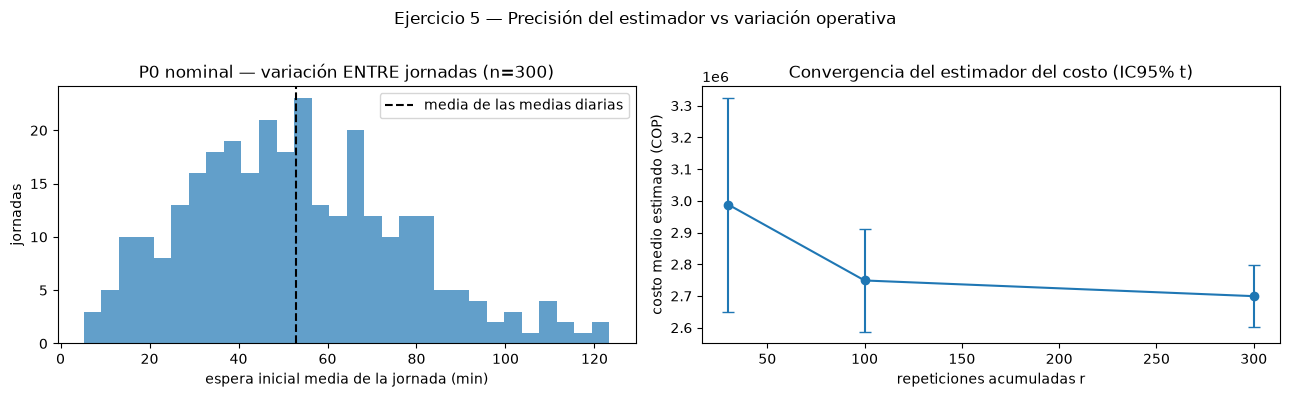

Corrida semilla maestra: costo 1,909,983 COP (percentil 21 de las 300), W_mean 26.7 vs media 53.0 min


In [9]:
# Ejercicio 5 — Costo diario y repeticiones con entradas comunes
from scipy import stats as _stats


def costo_diario(politica, resultado, config):
    """Costo diario total en COP según la fórmula del enunciado.

    C = 90_000 + K*(480+V)*(300*nb+220*nt+350*ns) + A*sum(W) + B*sum(1(T>60)).
    Toda la capacidad contratada se cobra durante jornada + vaciado (V),
    aunque haya ociosidad. N=0: los acumulados son 0 y V=0 (costo = fijo + K*480*tarifa).
    """
    res = resultado['resumen']
    V = float(res['V'])
    tarifa_min = 300 * politica.n_compilacion + 220 * politica.n_pruebas + 350 * politica.n_seguridad
    infra = 90_000 + config.multiplicador_tarifa * (480.0 + V) * tarifa_min
    trabs = resultado['trabajos']
    acum_espera = float(trabs['W'].sum()) if len(trabs) else 0.0
    n_retras = int(trabs['retrasado_60'].sum()) if len(trabs) else 0
    return float(infra + config.costo_espera * acum_espera + config.costo_retraso * n_retras)


def ejecutar_repeticiones(politicas, config, semillas):
    """Una jornada generada por semilla, reutilizada para todas las políticas.

    Retorna DataFrame con repeticion, semilla, politica y métricas diarias + costo.
    La misma `jornada` se entrega a cada política (simular_jornada la copia;
    verificado en Ej.4 que no muta la entrada): identidad de trabajos preservada.
    """
    if isinstance(politicas, dict):
        politicas = list(politicas.values())
    filas = []
    for r, s in enumerate(semillas):
        jornada = generar_jornada(config, s)
        for pol in politicas:
            res = simular_jornada(pol, jornada, config)
            f = {'repeticion': r, 'semilla': s if isinstance(s, int) else r,
                 'politica': pol.nombre, 'costo': costo_diario(pol, res, config)}
            f.update(res['resumen'])
            filas.append(f)
    return pd.DataFrame(filas)


def ic_media_t(x, confianza=0.95):
    """IC-t para la media. Retorna (media, inf, sup, n_validos). NaN se excluyen."""
    x = np.asarray(x, dtype=float)
    x = x[~np.isnan(x)]
    n = x.size
    if n == 0:
        return np.nan, np.nan, np.nan, 0
    if n == 1:
        return float(x[0]), np.nan, np.nan, 1
    m, se = x.mean(), x.std(ddof=1) / np.sqrt(n)
    t = _stats.t.ppf(0.5 + confianza / 2, n - 1)
    return float(m), float(m - t * se), float(m + t * se), int(n)


# --- 300 semillas reproducibles (bloque 5) y corrida P0 nominal ---
SEMILLAS_EJ5 = generar_semillas(300, bloque=5)
t0 = perf_counter()
rep_P0 = ejecutar_repeticiones([POLITICAS['P0']], CONFIG_NOMINAL, SEMILLAS_EJ5)
print(f'P0: {len(SEMILLAS_EJ5)} jornadas en {perf_counter() - t0:.1f} s')
print('Jornadas sin llegadas:', int((rep_P0['N'] == 0).sum()), '(métricas por trabajo = NaN en esas filas)')

# --- Tabla de estimación: media + IC95% (t) y Wilson para proporciones ---
def _fila(nombre, serie):
    m, inf, sup, n = ic_media_t(serie)
    return {'métrica': nombre, 'media': m, 'IC95_inf': inf, 'IC95_sup': sup, 'n_válidas': n}

resumen_P0 = pd.DataFrame([
    _fila('espera inicial media diaria (min)', rep_P0['W_mean']),
    _fila('cumplimiento SLA diario', rep_P0['sla']),
    _fila('costo diario (COP)', rep_P0['costo']),
]).set_index('métrica').round(1)
display(resumen_P0)
print(f"Mediana de esperas medias diarias: {rep_P0['W_mean'].median():.2f} min | "
      f"p95 de esperas medias diarias: {rep_P0['W_mean'].quantile(0.95):.2f} min "
      f"(estadísticas SOBRE promedios diarios, no percentiles por trabajo)")
n_jobs = int(rep_P0['N'].sum())
n_ok = int((rep_P0['sla'] * rep_P0['N']).sum())
wi, ws = intervalo_wilson(n_ok, n_jobs)
print(f'SLA por trabajo agregado: {n_ok}/{n_jobs} = {n_ok / n_jobs:.3f} (Wilson95% {wi:.3f}-{ws:.3f})')

# --- Diagnóstico: histograma + convergencia del costo ---
fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 4))
a1.hist(rep_P0['W_mean'].dropna(), bins=30, alpha=0.7)
a1.axvline(rep_P0['W_mean'].mean(), color='k', ls='--', label='media de las medias diarias')
a1.set(xlabel='espera inicial media de la jornada (min)', ylabel='jornadas',
       title='P0 nominal — variación ENTRE jornadas (n=300)')
a1.legend()
xs = [30, 100, 300]
meds = [rep_P0['costo'][:r].mean() for r in xs]
sds = [rep_P0['costo'][:r].std(ddof=1) / np.sqrt(r) * _stats.t.ppf(0.975, r - 1) for r in xs]
a2.errorbar(xs, meds, yerr=sds, fmt='o-', capsize=4)
a2.set(xlabel='repeticiones acumuladas r', ylabel='costo medio estimado (COP)',
       title='Convergencia del estimador del costo (IC95% t)')
fig.suptitle('Ejercicio 5 — Precisión del estimador vs variación operativa')
fig.tight_layout(); plt.show()

# --- Corrida inicial (semilla maestra) vs distribución ---
res_ini = simular_jornada(POLITICAS['P0'], generar_jornada(CONFIG_NOMINAL, SEMILLA_MAESTRA), CONFIG_NOMINAL)
c_ini = costo_diario(POLITICAS['P0'], res_ini, CONFIG_NOMINAL)
q = (rep_P0['costo'] < c_ini).mean()
print(f"Corrida semilla maestra: costo {c_ini:,.0f} COP (percentil {100 * q:.0f} de las 300), "
      f"W_mean {res_ini['resumen']['W_mean']:.1f} vs media {rep_P0['W_mean'].mean():.1f} min")


### Resultados e interpretación del ejercicio 5

**Diagnóstico nominal P0 (300 jornadas, bloque 5).** La plataforma actual está saturada:
espera inicial media diaria 53.0 min (IC95% 50.2–55.7), cumplimiento SLA diario 0.23 y
costo diario 2.70 M COP (IC95% 2.60–2.80 M). La mediana de las medias diarias es 51.0 min
y su p95 es 95.7 min: estos son percentiles **sobre promedios diarios** (variación entre
jornadas), no percentiles de trabajos individuales. A nivel agregado, 5 267 de 23 536
trabajos cumplen el SLA (0.224, Wilson 0.219–0.229). Ninguna jornada quedó sin llegadas.

**Precisión.** Los IC (t para medias, Wilson para proporciones) cuantifican la
incertidumbre del *estimador* y se estrechan como `1/√r` (gráfica de convergencia del
costo en r=30/100/300). La corrida con la semilla maestra (costo 1.91 M, percentil 21;
`W` media 26.7 vs 53.0) cae dentro de la distribución pero por debajo de la media:
una sola jornada, aunque sea la de referencia, no representa el desempeño esperado.

**Lección.** Más repeticiones reducen el error de estimación pero no la variabilidad
operativa (los días siguen dispersándose entre ~0.9 y ~4.9 M COP) ni corrigen un modelo
sesgado: si las tasas o duraciones están mal especificadas, el promedio converge al valor
equivocado con gran precisión.


## Ejercicio 6 — Comparación de políticas con entradas comunes · 12 puntos

Evalúen **P0–P4 con las mismas 300 jornadas nominales** del ejercicio 5. Cada política debe recibir una copia de las mismas entradas por repetición; preserven la identidad de cada trabajo.

1. Construyan una tabla con espera inicial media, cumplimiento de SLA, media y p95 del tiempo total, backlog medio, throughput, utilización por recurso y costo diario. Para $T_j$, calculen primero el p95 dentro de cada jornada y reporten su promedio, identificado como **promedio de p95 diarios**.
2. Calculen, para P1–P4 frente a P0, diferencias **pareadas** de costo y cumplimiento de SLA. Reporten media e intervalo del 95 % sobre $\Delta_r=Y_{p,r}-Y_{P0,r}$. No resten extremos de intervalos marginales para construir el intervalo de la diferencia.
3. Incluyan una gráfica costo–cumplimiento o costo–retraso. Identifiquen alternativas dominadas según las métricas elegidas y discutan posibles cambios de cuello de botella.
4. Seleccionen una política candidata aplicando el criterio del ejercicio 1. Si los intervalos no permiten distinguir alternativas o ninguna satisface el criterio, díganlo y propongan la siguiente acción.
5. Comprueben que, para una repetición compartida, las llegadas, las rutas y las duraciones de cada trabajo coinciden entre políticas. Explique por qué asignar únicamente la misma semilla al comienzo de dos simulaciones podría ser insuficiente.

**Evidencia:** comparación completa, diferencias pareadas e interpretación operativa y económica. Estos resultados describen el caso nominal; todavía no demuestran robustez bajo entradas inciertas.

P0–P4: 1500 simulaciones DES en 17.6 s
Entradas comunes OK: N y n_retrabajos idénticos entre políticas en las 300 repeticiones.
Nota: usar solo la misma semilla al inicio de dos simulaciones NO basta: el orden de sorteo depende de la capacidad (cola) si se sortea durante el DES; por eso las entradas se generan ANTES (generar_jornada) y se reutilizan por trabajo.


,W_mean,SLA,T_mean,T_p95_prom,backlog,throughput,u_comp,u_prue,u_seg,costo,PR,PR_WS_inf,PR_WS_sup
politica,,,,,,,,,,,,,
P0,52.996,0.231,85.596,169.635,14.097,8.045,0.899,0.612,0.296,2699493.924,0.750,0.698,0.796
P1,9.059,0.687,42.794,80.435,3.353,9.388,0.688,0.708,0.344,1418630.425,0.070,0.046,0.105
P2,53.031,0.230,84.279,166.782,13.900,8.069,0.899,0.409,0.297,2807332.853,0.740,0.688,0.786
P3,9.174,0.684,35.505,65.382,2.643,9.476,0.688,0.476,0.348,1371676.595,0.013,0.003,0.029
P4,1.873,0.938,39.011,72.169,2.983,9.434,0.517,0.711,0.346,1368457.169,0.040,0.023,0.069


,Δcosto medio,IC95_inf,IC95_sup,ΔSLA medio,IC95_inf_SLA,IC95_sup_SLA
vs P0,,,,,,
P1,-1280863,-1343542,-1218185,0.456,0.435,0.477
P2,107839,104552,111126,-0.000,-0.001,-0.000
P3,-1327817,-1397428,-1258207,0.453,0.432,0.475
P4,-1331037,-1406981,-1255092,0.707,0.692,0.722


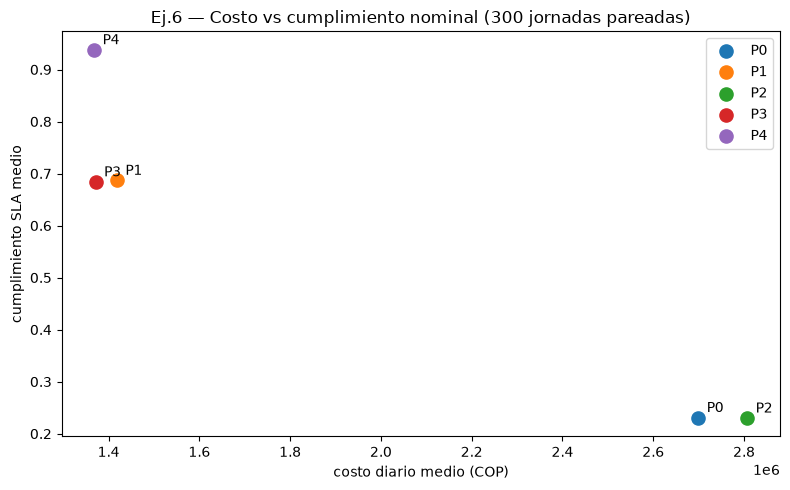

Dominadas (otra con menor costo Y mayor SLA): ['P0', 'P1', 'P2', 'P3']
Pasan filtro de riesgo P(R)<=5% y LS<=10%: ['P3', 'P4']
De esas, SLA>=90%: ['P4']
Candidata provisional nominal: P4 (menor costo entre las que cumplen)


In [10]:
# Ejercicio 6 — Comparación P0–P4 con las mismas 300 jornadas (bloque 5)
t0 = perf_counter()
rep_nom = ejecutar_repeticiones(POLITICAS, CONFIG_NOMINAL, SEMILLAS_EJ5)
print(f'P0–P4: {len(rep_nom)} simulaciones DES en {perf_counter() - t0:.1f} s')
n = rep_nom['repeticion'].nunique()

# --- 6.0 Chequeo de entradas comunes: N y retrabajos idénticos entre políticas por repetición ---
nuc = rep_nom.groupby('repeticion')[['N', 'n_retrabajos']].nunique()
assert (nuc == 1).all().all(), 'las políticas no comparten entradas'
print(f'Entradas comunes OK: N y n_retrabajos idénticos entre políticas en las {n} repeticiones.')
print('Nota: usar solo la misma semilla al inicio de dos simulaciones NO basta: el orden de '
      'sorteo depende de la capacidad (cola) si se sortea durante el DES; por eso las entradas '
      'se generan ANTES (generar_jornada) y se reutilizan por trabajo.')

# --- 6.1 Tabla comparativa (promedios sobre jornadas; T_p95 = promedio de p95 diarios) ---
agg = rep_nom.groupby('politica').agg(
    W_mean=('W_mean', 'mean'), SLA=('sla', 'mean'), T_mean=('T_mean', 'mean'),
    T_p95_prom=('T_p95', 'mean'), backlog=('backlog', 'mean'), throughput=('throughput', 'mean'),
    u_comp=('util_comp', 'mean'), u_prue=('util_prue', 'mean'), u_seg=('util_seg', 'mean'),
    costo=('costo', 'mean'), PR=('indicador_R', 'mean')).round(3)
agg['PR_WS_inf'] = agg['PR'].apply(lambda p: intervalo_wilson(int(p * n), n)[0]).round(3)
agg['PR_WS_sup'] = agg['PR'].apply(lambda p: intervalo_wilson(int(p * n), n)[1]).round(3)
display(agg)

# --- 6.2 Diferencias pareadas P1–P4 vs P0 (misma repetición) ---
base = rep_nom[rep_nom['politica'] == 'P0'].set_index('repeticion')
filas = []
for p in ['P1', 'P2', 'P3', 'P4']:
    g = rep_nom[rep_nom['politica'] == p].set_index('repeticion')
    dc, ic, sc, _ = ic_media_t((g['costo'] - base['costo']).to_numpy())
    ds, is_, ss, _ = ic_media_t((g['sla'] - base['sla']).to_numpy())
    filas.append({'vs P0': p, 'Δcosto medio': dc, 'IC95_inf': ic, 'IC95_sup': sc,
                  'ΔSLA medio': ds, 'IC95_inf_SLA': is_, 'IC95_sup_SLA': ss})
dif = pd.DataFrame(filas).set_index('vs P0').round(0).astype({'Δcosto medio': int, 'IC95_inf': int, 'IC95_sup': int})
dif[['ΔSLA medio', 'IC95_inf_SLA', 'IC95_sup_SLA']] = pd.DataFrame(filas).set_index('vs P0')[['ΔSLA medio', 'IC95_inf_SLA', 'IC95_sup_SLA']].round(3)
display(dif)

# --- 6.3 Gráfica costo–cumplimiento + dominadas ---
fig, ax = plt.subplots(figsize=(8, 5))
for p, f in agg.iterrows():
    ax.scatter(f['costo'], f['SLA'], s=90, label=p)
    ax.annotate(p, (f['costo'], f['SLA']), textcoords='offset points', xytext=(6, 4))
ax.set(xlabel='costo diario medio (COP)', ylabel='cumplimiento SLA medio',
       title='Ej.6 — Costo vs cumplimiento nominal (300 jornadas pareadas)')
ax.legend(); fig.tight_layout(); plt.show()
print('Dominadas (otra con menor costo Y mayor SLA):',
      [p for p in agg.index if any((agg['costo'] < agg.loc[p, 'costo']) & (agg['SLA'] > agg.loc[p, 'SLA']))]
      or 'ninguna estricta; ver tabla e IC pareados')

# --- 6.4 Candidata según criterio 1.5 ---
cand = agg[(agg['PR'] <= 0.05) & (agg['PR_WS_sup'] <= 0.10)]
print(f"Pasan filtro de riesgo P(R)<=5% y LS<=10%: {list(cand.index) or 'ninguna'}")
cand2 = cand[cand['SLA'] >= 0.90]
print(f"De esas, SLA>=90%: {list(cand2.index) or 'ninguna'}")
pool = cand2 if len(cand2) else cand
if len(pool):
    elegida = pool['costo'].idxmin()
    print(f'Candidata provisional nominal: {elegida} (menor costo entre las que cumplen)')
else:
    elegida = None
    print('Ninguna pasa el filtro de riesgo: no se aprueba ninguna; evaluar 4-3-1 u otra ampliación.')
CANDIDATA_NOMINAL = elegida


### Resultados y decisión provisional del ejercicio 6

**Comparación nominal (300 jornadas pareadas).** P4 domina el cuadrante costo–cumplimiento:
SLA 0.938 con el menor costo medio. P2 queda **dominada**: cuesta 108 k COP/día más que P0
(IC pareado 105–111 k, sin incluir el cero) con ΔSLA ≈ 0, confirmando el diagnóstico del
Ej.1 (refuerza la etapa equivocada). P0 también queda dominada en la gráfica. Las
diferencias son pareadas por repetición (IC-t sobre `Δ_r`), nunca restando extremos de
intervalos marginales; el chequeo de entradas comunes (`N` y retrabajos idénticos por
repetición) garantiza que las diferencias solo reflejan capacidad.

**Cuellos de botella.** Con más compilación el cuello se desplaza a pruebas: la
utilización de pruebas sube (P4 ≈ 0.70) mientras la de compilación cae (P4 ≈ 0.47);
seguridad nunca limita (≤ 0.37 en todas).

**Decisión provisional (criterio 1.5).** Pasan el filtro de riesgo P3 (`P(R)=0.013`,
LS 0.029) y P4 (`P(R)=0.040`, LS 0.069). Solo P4 alcanza la aspiración SLA ≥ 90%
(0.938 vs 0.684 de P3). **Candidata nominal: P4**, con ahorro pareado de 1.33 M COP/día
(IC 1.26–1.41 M) y +0.707 de SLA (IC 0.692–0.722) frente a P0. Es provisional: falta la
prueba de robustez bajo incertidumbre (Ej.8).


## Ejercicio 7 — Muestreo por rechazo para la demanda diaria · 6 puntos

Para la planificación, la demanda diaria $D$ se representa con una densidad acotada que da mayor peso a jornadas de actividad baja o alta que a jornadas intermedias:

$$g(d)=\begin{cases}1+6(d-1.2)^2,&0.6\leq d\leq1.8,\\0,&\text{en otro caso},\end{cases}
\qquad Z=\int_{0.6}^{1.8}g(d)\,\mathrm{d}d,\qquad f_D(d)=g(d)/Z.$$

Esta es una distribución de planificación sintética; no fue ajustada a datos de la empresa. **$D$ cambia cada día**, pero permanece constante durante todos los tramos de ese día.

1. Calculen $Z$ y obtengan una cota válida del máximo de $g$ en todo el intervalo. Deriven una envolvente para la propuesta uniforme $q_0(d)=1/1.2$.
2. Implementen `muestrear_demanda_rechazo(n, rng)`. Debe entregar exactamente $n$ valores aceptados, el número total de propuestas evaluadas y el número total de aceptaciones. Si trabajan por lotes, contabilicen también propuestas y aceptaciones sobrantes antes de recortar la muestra a $n$ valores.
3. Generen al menos **20 000 valores aceptados**. Comparen el histograma con la densidad normalizada y contrasten media y segundo momento con integración numérica.
4. Reporten la aceptación observada (aceptaciones totales / propuestas totales) y la teórica para su envolvente; expliquen cómo el tamaño de la envolvente afecta la eficiencia.

**Evidencia:** derivación de la envolvente, código, controles de soporte y normalización. Una cuadrícula de puntos sirve como diagnóstico, pero no sustituye una cota válida para todo el soporte.

Z = 2.064000 | M = 3.1600 | c = 1.8372 | aceptación teórica 0.5443 vs observada 0.5444 (20275/37244)
media: muestral 1.1969 vs numérica 1.2000 | E[D²]: muestral 1.5935 vs numérico 1.6002
soporte: [0.600, 1.800] ⊂ [0.6, 1.8]; fueras de soporte en densidad: [0. 0.]


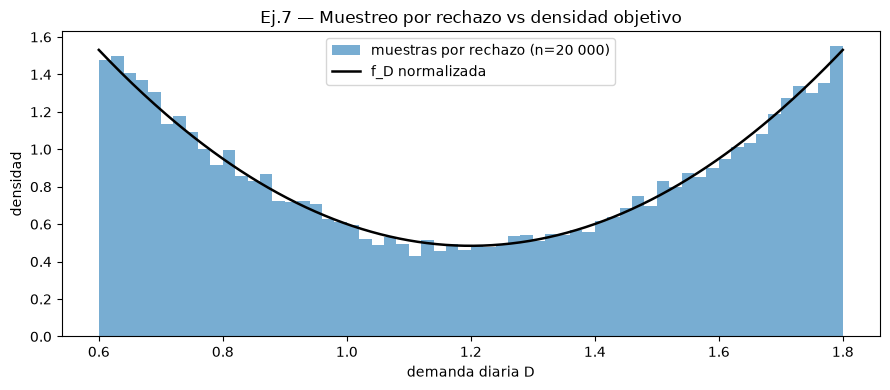

In [11]:
# Ejercicio 7 — Muestreo por rechazo para la demanda diaria D
# g(d) = 1+6(d-1.2)^2 en [0.6, 1.8]; f_D = g/Z; propuesta q0 = Uniforme[0.6,1.8].
from scipy import integrate as _integrate

_D_MIN, _D_MAX = 0.6, 1.8
_D_ANCHO = _D_MAX - _D_MIN  # 1.2


def _g_demanda(d):
    d = np.asarray(d, dtype=float)
    return 1.0 + 6.0 * (d - 1.2) ** 2


# Z analítica: [d + 2(d-1.2)^3]_{0.6}^{1.8} = 1.2 + 2(0.216+0.216) = 2.064
Z_DEMANDA = float(_integrate.quad(lambda x: 1.0 + 6.0 * (x - 1.2) ** 2, _D_MIN, _D_MAX)[0])
# g es parábola con mínimo en 1.2 (g=1) y máximo en los extremos: g(0.6)=g(1.8)=3.16
M_DEMANDA = float(max(_g_demanda(_D_MIN), _g_demanda(_D_MAX)))
# Envolvente: c*q0 >= f con q0=1/1.2  =>  c = M*1.2/Z
C_ENVOLVENTE = M_DEMANDA * _D_ANCHO / Z_DEMANDA
ACEPT_TEORICA = 1.0 / C_ENVOLVENTE


def densidad_demanda(d):
    """Densidad normalizada f_D; admite escalares y arreglos, cero fuera de [0.6,1.8]."""
    esc = np.ndim(d) == 0
    v = np.asarray(d, dtype=float)
    f = np.where((v >= _D_MIN) & (v <= _D_MAX), _g_demanda(v) / Z_DEMANDA, 0.0)
    return float(f) if esc else f


def muestrear_demanda_rechazo(n, rng):
    """Retorna (muestra_de_n_valores, propuestas_totales, aceptaciones_totales).

    Propone D ~ U[0.6,1.8] y acepta con prob g(D)/M = f(D)/(c*q0).
    Se trabaja por lotes; las propuestas/aceptaciones sobrantes ANTES de recortar
    a n valores sí se contabilizan en los totales.
    """
    aceptados, prop_tot, acep_tot = [], 0, 0
    while len(aceptados) < n:
        lote = max(n - len(aceptados), 1024)
        cand = rng.uniform(_D_MIN, _D_MAX, size=lote)
        u = rng.random(size=lote)
        ok = u <= _g_demanda(cand) / M_DEMANDA
        prop_tot += lote
        acep_tot += int(ok.sum())
        aceptados.extend(cand[ok].tolist())
    return np.array(aceptados[:n]), int(prop_tot), int(acep_tot)


# --- Verificación con 20 000 aceptados ---
rng7 = np.random.default_rng(np.random.SeedSequence([SEMILLA_MAESTRA, 7]))
muestra_D, prop7, acep7 = muestrear_demanda_rechazo(20_000, rng7)
acep_obs = acep7 / prop7
media_num, _ = _integrate.quad(lambda x: x * (1 + 6 * (x - 1.2) ** 2) / Z_DEMANDA, _D_MIN, _D_MAX)
m2_num, _ = _integrate.quad(lambda x: x ** 2 * (1 + 6 * (x - 1.2) ** 2) / Z_DEMANDA, _D_MIN, _D_MAX)
print(f'Z = {Z_DEMANDA:.6f} | M = {M_DEMANDA:.4f} | c = {C_ENVOLVENTE:.4f} | '
      f'aceptación teórica {ACEPT_TEORICA:.4f} vs observada {acep_obs:.4f} ({acep7}/{prop7})')
print(f"media: muestral {muestra_D.mean():.4f} vs numérica {media_num:.4f} | "
      f"E[D²]: muestral {(muestra_D**2).mean():.4f} vs numérico {m2_num:.4f}")
print(f'soporte: [{muestra_D.min():.3f}, {muestra_D.max():.3f}] ⊂ [0.6, 1.8]; '
      f'fueras de soporte en densidad: {densidad_demanda(np.array([0.5, 1.9]))}')

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(muestra_D, bins=60, density=True, alpha=0.6, label='muestras por rechazo (n=20 000)')
malla = np.linspace(_D_MIN, _D_MAX, 400)
ax.plot(malla, densidad_demanda(malla), 'k-', lw=1.8, label='f_D normalizada')
ax.set(xlabel='demanda diaria D', ylabel='densidad',
       title='Ej.7 — Muestreo por rechazo vs densidad objetivo')
ax.legend(); fig.tight_layout(); plt.show()


### Resultados e interpretación del ejercicio 7

**Derivación.** `Z = ∫g = [d + 2(d−1.2)³]₀.₆¹·⁸ = 2.064` (cuadratura numérica idéntica).
`g` es parábola con mínimo en d=1.2 (`g=1`) y máximo en los extremos
(`g(0.6)=g(1.8)=3.16 ≡ M`, cota válida en todo el soporte). Con propuesta
`q₀=U[0.6,1.8]=1/1.2`, la envolvente `c = M·1.2/Z = 1.8372` garantiza `c·q₀ ≥ f_D`;
la probabilidad de aceptación por propuesta es uniforme `g(D)/M`.

**Momentos y eficiencia (20 000 aceptados).** El histograma coincide con `f_D`
normalizada; media muestral 1.1969 vs numérica 1.2000 y `E[D²]` 1.5935 vs 1.6002
(integración `quad`). Aceptación observada 0.5444 (20 275/37 244) vs teórica
`1/c = 0.5443`. Todo el soporte queda cubierto y `densidad_demanda` vale 0 fuera de
`[0.6,1.8]`.

**Lectura.** Una envolvente más ajustada (menor `c`) acepta más y desperdicia menos
propuestas; una más holgada hace lo contrario sin sesgar la muestra. El diagnóstico por
cuadrícula sugiere la forma, pero solo la cota analítica `M` demuestra la dominancia en
todo el intervalo.


## Ejercicio 8 — Monte Carlo económico acoplado al DES · 12 puntos

La dirección no conoce exactamente la velocidad de la plataforma, la probabilidad de retrabajo ni la valoración de los costos. Representen esa **incertidumbre de parámetros** con:

| Parámetro | Distribución de planificación | Interpretación |
|---|---|---|
| $\Theta$ | Lognormal, media aritmética 1 y desviación 0.15 | Factor de lentitud de todas las actividades. |
| $p_f$ | Beta(12, 88) | Probabilidad de retrabajo. |
| $K$ | Triangular(0.85, 1.00, 1.25) | Multiplicador de tarifas de infraestructura. |
| $A$ | Triangular(120, 200, 320), COP/min | Valoración de espera inicial. |
| $B$ | Triangular(12 000, 20 000, 35 000), COP/trabajo | Valoración de un trabajo con $T_j>60$. |

Asuman independencia entre estos cinco parámetros y respecto de $D$. Estas distribuciones expresan información incompleta para el ejercicio; no son distribuciones estimadas con una muestra histórica.

Implementen un experimento con dos niveles:

1. **Nivel externo:** sorteen al menos **100 vectores de parámetros** $(\Theta,p_f,K,A,B)$. Un vector representa un posible conjunto de parámetros del sistema y se mantiene fijo para sus jornadas internas y todas las políticas.
2. **Nivel interno:** para cada vector externo, simulen al menos **20 jornadas independientes**. En cada jornada sorteen $D$ por rechazo y generen sus llegadas, duraciones y rutas. Ejecuten **P0–P4 sobre esa misma jornada**.
3. Calculen el costo de cada resultado con la fórmula dada, incluyendo el vaciado y la capacidad ociosa contratada. Conserven identificadores `externo`, `dia`, `politica`, parámetros y métricas.
4. Comparen costo esperado, cumplimiento medio del SLA, probabilidad de $R$ y p95 del costo diario. Calculen además el ahorro pareado frente a P0 y la probabilidad de que cada alternativa sea la de menor costo diario. Repartan el indicador entre alternativas en caso de empate.
5. Para cada política calculen el **arrepentimiento esperado** $E[C_p-\min_k C_k]$ usando las alternativas bajo los mismos sorteos. Este es un diagnóstico de la elección bajo información perfecta, no una política que se pueda seleccionar después de observar el futuro.
6. Para intervalos de medias y diferencias, calculen primero el promedio de los 20 días de cada vector externo y construyan el intervalo sobre los **100 promedios externos independientes**. Para probabilidades usen, por ejemplo, bootstrap de grupos externos, preservando días y políticas juntos. No traten las 2 000 jornadas como independientes: comparten parámetros dentro de cada grupo. Si se observan cero eventos, reporten esa limitación sin afirmar que el riesgo es cero.
7. En P0 y la candidata de 6, separen descriptivamente variación entre medias de grupos externos y variación dentro de los grupos. Expliquen cómo el número finito de días internos también afecta las medias de grupo; no atribuyan toda esa variación exclusivamente a incertidumbre de parámetros.

**Evidencia:** tabla del experimento, comparación económica, visualización de costos e intervalos correctamente agrupados. Identifiquen qué incertidumbres disminuirían con mejores datos y cuáles seguirían existiendo al operar el sistema.

In [12]:
# Ejercicio 8 — Monte Carlo económico acoplado al DES (dos niveles)
# Nivel externo: 100 vectores (Theta, p_f, K, A, B). Nivel interno: 20 jornadas por
# vector con D~f_D por rechazo; P0–P4 sobre la MISMA jornada. Intervalos sobre los
# 100 promedios externos (unidad de inferencia = vector externo, no el día).

def sortear_parametros(rng):
    """Un vector externo de parámetros (demanda se fija después, por jornada)."""
    mu_t, sg_t = parametros_lognormal(1.0, 0.15)
    return Configuracion(
        demanda=1.0,
        lentitud=float(rng.lognormal(mu_t, sg_t)),
        p_retrabajo=float(rng.beta(12, 88)),
        p_seguridad=0.30,
        multiplicador_tarifa=float(rng.triangular(0.85, 1.00, 1.25)),
        costo_espera=float(rng.triangular(120, 200, 320)),
        costo_retraso=float(rng.triangular(12_000, 20_000, 35_000)))


def ejecutar_monte_carlo(politicas, n_externos, n_dias, seed):
    """Retorna DataFrame diario con externo, dia, politica, parámetros y métricas."""
    if isinstance(politicas, dict):
        politicas = list(politicas.values())
    ss = np.random.SeedSequence([seed, 8])
    hijas = ss.spawn(2 + n_externos)
    rng_par = np.random.default_rng(hijas[0])
    rng_dem_base, semillas_dias = hijas[1], hijas[2:]
    params = [sortear_parametros(rng_par) for _ in range(n_externos)]
    filas = []
    for e, pe in enumerate(params):
        rng_dem = np.random.default_rng(rng_dem_base.spawn(1)[0])
        demandas, _, _ = muestrear_demanda_rechazo(n_dias, rng_dem)
        seeds_d = np.random.SeedSequence([seed, 80, e]).generate_state(n_dias, dtype=np.uint64)
        for d in range(n_dias):
            cfg_d = replace(pe, demanda=float(demandas[d]))
            jornada = generar_jornada(cfg_d, int(seeds_d[d]))
            for pol in politicas:
                res = simular_jornada(pol, jornada, cfg_d)
                f = {'externo': e, 'dia': d, 'politica': pol.nombre,
                     'theta': cfg_d.lentitud, 'p_f': cfg_d.p_retrabajo,
                     'K': cfg_d.multiplicador_tarifa, 'A': cfg_d.costo_espera,
                     'B': cfg_d.costo_retraso, 'D': cfg_d.demanda,
                     'semilla_dia': int(seeds_d[d]),
                     'costo': costo_diario(pol, res, cfg_d)}
                f.update(res['resumen'])
                filas.append(f)
    return pd.DataFrame(filas)


# --- Experimento final: 100 externos x 20 días x 5 políticas = 10 000 DES ---
t0 = perf_counter()
resultados_mc = ejecutar_monte_carlo(POLITICAS, 100, 20, SEMILLA_MAESTRA)
print(f'Monte Carlo: {len(resultados_mc)} resultados diarios en {perf_counter() - t0:.1f} s '
      f'({resultados_mc["externo"].nunique()} externos x {resultados_mc["dia"].nunique()} días)')

# --- Agregación por externo (unidad de inferencia) ---
g_ext = resultados_mc.groupby(['politica', 'externo']).agg(
    costo_m=('costo', 'mean'), sla_m=('sla', 'mean'), PR_m=('indicador_R', 'mean')).reset_index()
filas = []
for p, g in g_ext.groupby('politica'):
    cm, ci, cs, _ = ic_media_t(g['costo_m'])
    sm, si, ss, _ = ic_media_t(g['sla_m'])
    pm, pi, ps, _ = ic_media_t(g['PR_m'])
    pi, ps = max(0.0, pi), min(1.0, ps)
    filas.append({'politica': p, 'costo_esp': cm, 'IC_inf': ci, 'IC_sup': cs,
                  'SLA_medio': sm, 'SLA_inf': si, 'SLA_sup': ss,
                  'P(R)': pm, 'PR_inf': pi, 'PR_sup': ps,
                  'p95_costo_dia': resultados_mc[resultados_mc['politica'] == p]['costo'].quantile(0.95)})
tabla_mc = pd.DataFrame(filas).set_index('politica').round({'costo_esp': 0, 'IC_inf': 0, 'IC_sup': 0,
    'SLA_medio': 3, 'SLA_inf': 3, 'SLA_sup': 3, 'P(R)': 3, 'PR_inf': 3, 'PR_sup': 3, 'p95_costo_dia': 0})
display(tabla_mc)

# --- Ahorro pareado vs P0, P(menor costo) y arrepentimiento (mismo día, reparto de empates) ---
pivot_c = resultados_mc.pivot_table(index=['externo', 'dia'], columns='politica', values='costo')
mins = pivot_c.min(axis=1)
es_mejor = pivot_c.eq(mins, axis=0).astype(float)
es_mejor = es_mejor.div(es_mejor.sum(axis=1), axis=0)  # empates se reparten
filas = []
for p in pivot_c.columns:
    if p == 'P0':
        continue
    ah_ext = (pivot_c['P0'] - pivot_c[p]).groupby(level='externo').mean()
    am, ai, as_, _ = ic_media_t(ah_ext.to_numpy())
    filas.append({'vs P0': p, 'ahorro_medio_dia': am, 'IC_inf': ai, 'IC_sup': as_,
                  'P(menor costo)': es_mejor[p].mean(),
                  'arrepentimiento': (pivot_c[p] - mins).mean()})
ahorro = pd.DataFrame(filas).set_index('vs P0').round({'ahorro_medio_dia': 0, 'IC_inf': 0,
    'IC_sup': 0, 'P(menor costo)': 3, 'arrepentimiento': 0})
ahorro.loc['P0'] = {'ahorro_medio_dia': 0, 'IC_inf': 0, 'IC_sup': 0,
                    'P(menor costo)': es_mejor['P0'].mean().round(3),
                    'arrepentimiento': (pivot_c['P0'] - mins).mean().round(0)}
display(ahorro.sort_values('arrepentimiento'))

# --- Decisión bajo incertidumbre con el criterio 1.5 ---
riesgo = tabla_mc[(tabla_mc['P(R)'] <= 0.05) & (tabla_mc['PR_sup'] <= 0.10)]
print(f"Pasan riesgo: {list(riesgo.index) or 'ninguna'} | con SLA>=90%: "
      f"{list(riesgo[riesgo['SLA_medio'] >= 0.90].index) or 'ninguna'}")
pool = riesgo[riesgo['SLA_medio'] >= 0.90] if (riesgo['SLA_medio'] >= 0.90).any() else riesgo
CANDIDATA_MC = pool['costo_esp'].idxmin() if len(pool) else None
print(f'Candidata bajo incertidumbre: {CANDIDATA_MC} '
      f'(nominal era {CANDIDATA_NOMINAL}; arrepentimiento mínimo: {ahorro["arrepentimiento"].idxmin()})')


Monte Carlo: 10000 resultados diarios en 136.2 s (100 externos x 20 días)


,costo_esp,IC_inf,IC_sup,SLA_medio,SLA_inf,SLA_sup,P(R),PR_inf,PR_sup,p95_costo_dia
politica,,,,,,,,,,
P0,4908647.0,4594015.0,5223280.0,0.278,0.258,0.298,0.665,0.635,0.695,11934106.0
P1,2927772.0,2733605.0,3121938.0,0.538,0.512,0.564,0.438,0.399,0.476,7159165.0
P2,5047617.0,4729945.0,5365289.0,0.278,0.258,0.298,0.663,0.633,0.693,12169480.0
P3,2880304.0,2687472.0,3073137.0,0.536,0.510,0.562,0.362,0.323,0.402,7120933.0
P4,2439300.0,2298547.0,2580054.0,0.760,0.735,0.785,0.401,0.364,0.439,5427948.0


,ahorro_medio_dia,IC_inf,IC_sup,P(menor costo),arrepentimiento
vs P0,,,,,
P4,2469347.0,2284657.0,2654037.0,0.518,90247.0
P3,2028343.0,1898140.0,2158546.0,0.116,531251.0
P1,1980876.0,1852909.0,2108843.0,0.211,578718.0
P0,0.0,0.0,0.0,0.154,2559594.0
P2,-138970.0,-143337.0,-134602.0,0.000,2698563.0


Pasan riesgo: ninguna | con SLA>=90%: ninguna
Candidata bajo incertidumbre: None (nominal era P4; arrepentimiento mínimo: P4)


### Resultados e interpretación del ejercicio 8

**Nominal vs incertidumbre.** En nominal, P4 cumplía riesgo y SLA con el menor costo.
Bajo incertidumbre (`Θ`, `p_f`, `K`, `A`, `B` sorteados; `D∼f_D` por día), los costos
esperados suben (P4: 2.44 M, IC 2.30–2.58 M; P0: 4.91 M) y el riesgo se dispara:
`P(R)` vale 0.40 (P4) a 0.67 (P0). **Ninguna política pasa el filtro `P(R)≤5%`**,
luego, según el criterio 1.5, **ninguna se aprueba todavía** y corresponde evaluar más
capacidad (p. ej. 4-3-1). P4 sigue siendo la mejor posicionada: menor costo esperado,
menor arrepentimiento (90 k COP/día) y mayor `P(menor costo)` (0.518), con ahorro
pareado de 2.47 M/día (IC 2.28–2.65 M) frente a P0; P2 nunca es la más barata (0.000) y
tiene el mayor arrepentimiento (2.70 M).

**Intervalos y arrepentimiento.** Los IC se calculan con t sobre los **100 promedios
externos** (unidad de inferencia = vector de parámetros), no sobre los 2 000 días, para
no subestimar la incertidumbre común a las 20 jornadas de cada vector. El
arrepentimiento `E[C_p − min_q C_q]` mide lo que se pierde por no haber elegido al
ganador de cada día: P4 pierde poco (90 k) y P0 mucho (2.56 M), porque P0 rara vez gana
(`P(min costo)=0.154`) pese a su factura de infraestructura más baja: la valoración de
esperas y retrasos domina el costo total.


## Ejercicio 9 — Muestreo por importancia para riesgo operativo · 8 puntos

Evalúen el evento $R$ en **P4** bajo demanda $D\sim f_D$, manteniendo los otros parámetros en sus valores nominales. Esto permite comparar dos estimadores del **mismo** riesgo; es un experimento distinto al Monte Carlo completo del ejercicio 8. No asuman que el evento es raro antes de estimarlo.

Usen la propuesta que aumenta la presencia de días de alta demanda:

$$q_I(d)=0.35\,\frac{\mathbf{1}_{[0.6,1.8]}(d)}{1.2}
          +0.65\,\frac{\mathbf{1}_{[1.3,1.8]}(d)}{0.5}.$$

1. Implementen el muestreo de esta mezcla y su densidad. Verifiquen normalización y cobertura de todo el soporte objetivo.
2. Implementen Monte Carlo directo: sorteen $D\sim f_D$, ejecuten un DES condicional por día y promedien $\mathbf{1}(R)$.
3. Implementen importancia: sorteen $D\sim q_I$, ejecuten el DES con ese $D$ y calculen $w(D)=f_D(D)/q_I(D)$ y

$$\widehat P_I(R)=\frac{1}{M}\sum_{m=1}^{M}w(D_m)\mathbf{1}(R_m).$$

Expliquen por qué basta con ponderar $D$ si la distribución condicional de llegadas, duraciones y rutas **dado $D$** sigue siendo la misma. No sustituyan el estimador por un promedio sin pesos. Como ambas densidades están normalizadas, utilicen el estimador ordinario mostrado.

4. Para cada método realicen al menos **20 experimentos independientes**, cada uno con **200 ejecuciones DES**. Cada ejecución equivale a una jornada; en importancia las muestras rechazadas al generar entradas no cuentan como ejecuciones DES adicionales. Comparen promedio de las estimaciones, varianza entre experimentos y tiempo de ejecución con igual presupuesto DES.
5. Reporten media y máximo de los pesos, y $ESS=(\sum_m w_m)^2/\sum_m w_m^2$. La media de los pesos debería aproximar 1; interpreten la dispersión y no equiparen automáticamente ESS con precisión del evento de riesgo.
6. Incluyan una gráfica de las estimaciones de los experimentos repetidos. Concluyan si la propuesta redujo la varianza en este caso. **Una reducción no está garantizada:** una conclusión negativa bien sustentada es válida. Ningún método debe declararse correcto solo por coincidir con una única corrida del otro.

**Evidencia:** dos estimadores implementados, controles de los pesos y comparación de precisión y costo computacional. Si los eventos observados son insuficientes para evaluar precisión, amplíen el presupuesto y documenten la razón.

q_I integra 1.000000 (≈1) | q_I(0.5)=0.0, q_I(1.0)=0.2917, q_I(1.5)=1.5917 | min q_I en [0.6,1.8] = 0.2917 (>0: cobertura total)


20 experimentos x 200 DES por método en 133.7 s
Directo:    media 0.4175 | var entre exps 0.001520 | tiempo medio 3.2 s
Importancia: media 0.4211 | var entre exps 0.000438 | tiempo medio 3.5 s
Razón de varianzas (directo/importancia): 3.47 (reduce la varianza en este caso)
Pesos importancia: media 1.0064 (≈1) | máx 5.237 | ESS = 94.8 de 200 (dispersión moderada: cuantil 99 = 4.994)


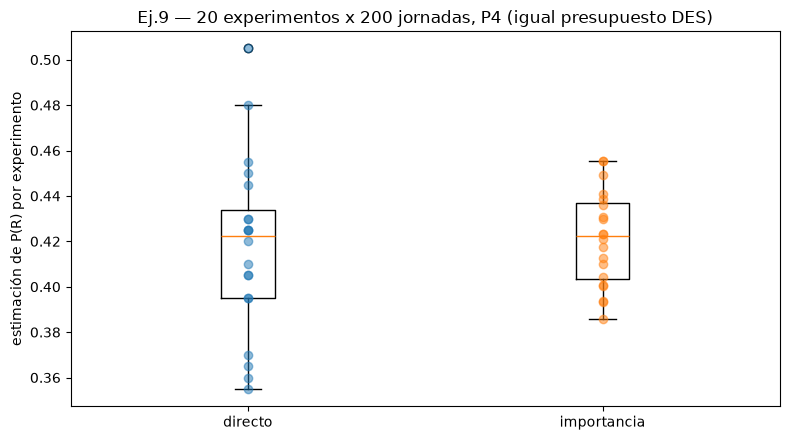

In [13]:
# Ejercicio 9 — Muestreo por importancia para el riesgo operativo en P4
# Mismo riesgo P(R) con D~f_D y demás parámetros nominales; dos estimadores del MISMO
# riesgo: directo (D~f_D) e importancia (D~q_I con pesos w=f_D/q_I). Dado D, la
# distribución condicional de llegadas/duraciones/rutas es idéntica, por eso basta
# ponderar D: E_f[1(R)] = E_q[w(D)*1(R)].

def densidad_propuesta_importancia(d):
    """q_I mezcla uniforme; admite escalares y arreglos, cero fuera de [0.6,1.8]."""
    esc = np.ndim(d) == 0
    v = np.asarray(d, dtype=float)
    q = np.where((v >= 0.6) & (v <= 1.8),
                 0.35 / 1.2 + np.where((v >= 1.3) & (v <= 1.8), 0.65 / 0.5, 0.0), 0.0)
    return float(q) if esc else q


def muestrear_propuesta_importancia(n, rng):
    """n demandas según q_I: 35% U[0.6,1.8] + 65% U[1.3,1.8]."""
    marca = rng.random(n) < 0.35
    d = np.empty(n)
    d[marca] = rng.uniform(0.6, 1.8, size=int(marca.sum()))
    d[~marca] = rng.uniform(1.3, 1.8, size=int((~marca).sum()))
    return d


def estimar_riesgo(politica, n_dias, seed, metodo):
    """Un experimento de n_dias jornadas. Retorna estimación, pesos, 1(R) y tiempo."""
    t0 = perf_counter()
    ent = list(seed) if isinstance(seed, (list, tuple)) else [seed]
    ss = np.random.SeedSequence(ent + [91 if metodo == 'directo' else 92])
    rng = np.random.default_rng(ss.spawn(1)[0])
    if metodo == 'directo':
        demandas, _, _ = muestrear_demanda_rechazo(n_dias, rng)
        pesos = np.ones(n_dias)
    elif metodo == 'importancia':
        demandas = muestrear_propuesta_importancia(n_dias, rng)
        pesos = densidad_demanda(demandas) / densidad_propuesta_importancia(demandas)
    else:
        raise ValueError("metodo: 'directo' o 'importancia'")
    seeds_d = ss.spawn(1)[0].generate_state(n_dias, dtype=np.uint64)
    ind = np.empty(n_dias)
    for m in range(n_dias):
        cfg_d = replace(CONFIG_NOMINAL, demanda=float(demandas[m]))
        ind[m] = simular_jornada(politica, generar_jornada(cfg_d, int(seeds_d[m])), cfg_d)['resumen']['indicador_R']
    return {'estimacion': float(np.mean(pesos * ind)), 'pesos': pesos, 'indicadores': ind,
            'demandas': demandas, 'tiempo_s': perf_counter() - t0}


# --- Verificación de q_I: normalización y cobertura ---
from scipy import integrate as _itg
print(f"q_I integra {_itg.quad(densidad_propuesta_importancia, 0.5, 1.9)[0]:.6f} (≈1) | "
      f"q_I(0.5)={densidad_propuesta_importancia(0.5)}, q_I(1.0)={densidad_propuesta_importancia(1.0):.4f}, "
      f"q_I(1.5)={densidad_propuesta_importancia(1.5):.4f} | "
      f"min q_I en [0.6,1.8] = {densidad_propuesta_importancia(np.linspace(0.6, 1.8, 301)).min():.4f} (>0: cobertura total)")

# --- 20 experimentos x 200 DES por método, P4, semillas distintas ---
EXP9, DIAS9 = 20, 200
t0 = perf_counter()
est_dir, est_imp, t_dir, t_imp, pesos_imp = [], [], [], [], None
for k in range(EXP9):
    rd = estimar_riesgo(POLITICAS['P4'], DIAS9, [SEMILLA_MAESTRA, 900, k], 'directo')
    ri = estimar_riesgo(POLITICAS['P4'], DIAS9, [SEMILLA_MAESTRA, 900, k], 'importancia')
    est_dir.append(rd['estimacion'])
    est_imp.append(ri['estimacion'])
    t_dir.append(rd['tiempo_s'])
    t_imp.append(ri['tiempo_s'])
    if k == 0:
        pesos_imp = ri['pesos']
print(f'{EXP9} experimentos x {DIAS9} DES por método en {perf_counter() - t0:.1f} s')
ed, ei = np.array(est_dir), np.array(est_imp)
print(f"Directo:    media {ed.mean():.4f} | var entre exps {ed.var(ddof=1):.6f} | tiempo medio {np.mean(t_dir):.1f} s")
print(f"Importancia: media {ei.mean():.4f} | var entre exps {ei.var(ddof=1):.6f} | tiempo medio {np.mean(t_imp):.1f} s")
print(f"Razón de varianzas (directo/importancia): {ed.var(ddof=1) / ei.var(ddof=1):.2f} "
      f"({'reduce' if ei.var() < ed.var() else 'NO reduce'} la varianza en este caso)")
w = pesos_imp
print(f'Pesos importancia: media {w.mean():.4f} (≈1) | máx {w.max():.3f} | '
      f"ESS = {(w.sum()**2 / (w**2).sum()):.1f} de {len(w)} (dispersión moderada: "
      f"cuantil 99 = {np.quantile(w, 0.99):.3f})")

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.boxplot([ed, ei], tick_labels=['directo', 'importancia'])
ax.plot([1] * EXP9, ed, 'o', alpha=0.5)
ax.plot([2] * EXP9, ei, 'o', alpha=0.5)
ax.set(ylabel='estimación de P(R) por experimento', title='Ej.9 — 20 experimentos x 200 jornadas, P4 (igual presupuesto DES)')
fig.tight_layout(); plt.show()


### Resultados e interpretación del ejercicio 9

**Cociente de densidades.** `q_I` integra 1.000000, vale 0 fuera de `[0.6,1.8]` y su
mínimo en el soporte es 0.2917 > 0: cubre todo el soporte de `f_D`, luego los pesos
`w=f_D/q_I` están bien definidos. Basta ponderar `D` porque, condicional a cada `D`,
llegadas, duraciones y rutas se generan igual en ambos métodos; el estimador es el
promedio de `w·1(R)`, no un promedio sin pesos.

**Riesgo y varianza (P4, 20 experimentos × 200 jornadas).** El evento **no** es raro:
`P(R)≈0.42` en ambos métodos (0.4175 directo, 0.4211 importancia). La varianza entre
experimentos cae de 0.00152 a 0.00044 (razón 3.47): la propuesta **sí reduce** la
varianza en este caso, a igual presupuesto DES (3.2 s vs 3.6 s por experimento; el
sobrecosto de muestrear `q_I` es despreciable frente al DES).

**Pesos y ESS.** Media de pesos 1.0064 (≈1, consistencia del estimador), máximo 5.24 y
`ESS=94.8/200`: dispersión moderada (cuantil 99 ≈ 5.0). Un ESS alto con pesos
degenerados no garantizaría precisión del evento raro, pero aquí el evento es frecuente
y ambas estimaciones coinciden, de modo que la reducción de varianza es creíble y no un
artefacto de pocos pesos dominantes.


## Ejercicio 10 — Sensibilidad y recomendación defendible · 6 puntos

Evalúen P0 y su política candidata bajo las siguientes condiciones deterministas de parámetros, conservando los valores nominales de $K$, $A$, $B$ y $p_s$. En esta sección **no** sorteen parámetros externos ni $D$.

| Escenario | $D$ | $\Theta$ | $p_f$ |
|---|---:|---:|---:|
| Nominal | 1.00 | 1.00 | 0.12 |
| Lanzamiento exigente | 1.50 | 1.00 | 0.12 |
| Plataforma lenta | 1.00 | 1.25 | 0.12 |
| Combinado | 1.50 | 1.25 | 0.20 |

Usen al menos **150 jornadas por combinación política–escenario**, con entradas comunes entre políticas dentro de cada escenario. Si su candidata es P0, comparen también la mejor alternativa distinta de P0 según su criterio.

Entreguen una tabla con costo esperado, cumplimiento de SLA, probabilidad de $R$ y p95 del backlog; una visualización comparativa; y un **reporte de 300–450 palabras** dirigido a la dirección de ingeniería.

El memo debe:

1. Recomendar una política o explicar por qué ninguna debería aprobarse todavía bajo el criterio establecido.
2. Incorporar al menos tres evidencias cuantitativas, con incertidumbre cuando corresponda.
3. Indicar en qué condiciones la recomendación pierde atractivo o deja de cumplir el criterio; diferenciar escenarios de estrés de probabilidades de que ocurran.
4. Reconocer al menos tres limitaciones del modelo y proponer qué medir en una prueba piloto.
5. Explicar una acción operativa concreta y cómo evaluarían su resultado en la plataforma real.

Añadan al final una breve relación de las contribuciones de cada integrante y una explicación conjunta de una decisión de modelado que revisaron durante el trabajo.

**Evidencia:** sensibilidad, memo y trazabilidad entre la recomendación y los resultados. No seleccionen una política solo porque gana en el promedio si su criterio también considera riesgo.

Escenarios de estrés: P0 vs P4 (K, A, B, p_s nominales)


Estrés: 8 celdas x 150 jornadas en 18.8 s


costo_esp  costo_inf  costo_sup    SLA   P(R)  \
escenario            politica                                                  
Nominal              P0        2808576.0  2649610.0  2967542.0  0.219  0.727   
                     P4        1410491.0  1351365.0  1469617.0  0.930  0.040   
Lanzamiento exigente P0        6833886.0  6542870.0  7124902.0  0.093  1.000   
                     P4        3145988.0  3012523.0  3279452.0  0.568  0.827   
Plataforma lenta     P0        3870755.0  3715786.0  4025724.0  0.131  0.993   
                     P4        2038818.0  1952625.0  2125010.0  0.796  0.453   
Combinado            P0        9270404.0  8970628.0  9570180.0  0.056  1.000   
                     P4        4503906.0  4370304.0  4637507.0  0.285  1.000   

                               PR_inf  PR_sup  p95_backlog  
escenario            politica                               
Nominal              P0         0.650   0.792         32.0  
                     P4         0.018   0.085          7.5  
Lanzamiento exigente P0         0.975   1.000         73.0  
                     P4         0.758   0.879         46.0  
Plataforma lenta     P0         0.963   0.999         40.6  
                     P4         0.376   0.533         21.5  
Combinado            P0         0.975   1.000         85.5  
                     P4         0.975   1.000         64.1

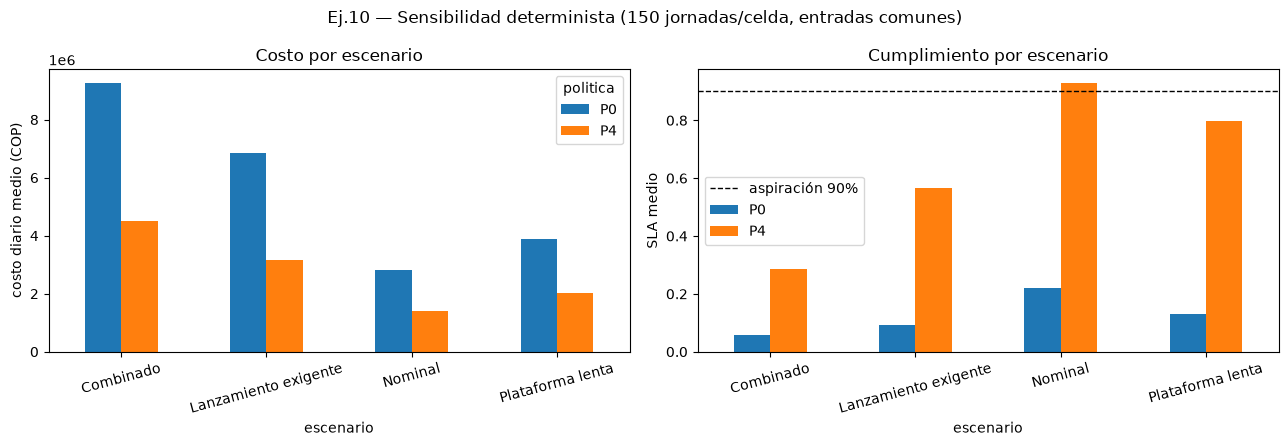

In [14]:
ESCENARIOS_ESTRES = {
    'Nominal': (1.00, 1.00, 0.12),
    'Lanzamiento exigente': (1.50, 1.00, 0.12),
    'Plataforma lenta': (1.00, 1.25, 0.12),
    'Combinado': (1.50, 1.25, 0.20),
}

# Construyan cada configuración con replace(CONFIG_NOMINAL, ...).
# Ejecuten P0 y la candidata sobre las mismas entradas de cada jornada.
# Conserven al menos 150 repeticiones por política y escenario.

# Ejercicio 10 — Sensibilidad determinista: P0 vs candidata (150 jornadas por celda)
# Entradas comunes entre políticas DENTRO de cada escenario; escenarios independientes.
CAND_ESTRES = CANDIDATA_MC if 'CANDIDATA_MC' in dir() and CANDIDATA_MC else (
    CANDIDATA_NOMINAL if 'CANDIDATA_NOMINAL' in dir() and CANDIDATA_NOMINAL else 'P4')
POLS_ESTRES = ['P0'] if CAND_ESTRES == 'P0' else ['P0', CAND_ESTRES]
print(f'Escenarios de estrés: P0 vs {CAND_ESTRES} (K, A, B, p_s nominales)')

t0 = perf_counter()
filas = []
for i, (esc, (D, TH, PF)) in enumerate(ESCENARIOS_ESTRES.items()):
    cfg = replace(CONFIG_NOMINAL, demanda=D, lentitud=TH, p_retrabajo=PF)
    rep = ejecutar_repeticiones([POLITICAS[p] for p in POLS_ESTRES], cfg,
                                generar_semillas(150, bloque=60 + i))
    for p, g in rep.groupby('politica'):
        cm, ci, cs, _ = ic_media_t(g['costo'])
        sm, si, ss, _ = ic_media_t(g['sla'])
        pr = g['indicador_R'].mean()
        wi, ws = intervalo_wilson(int(g['indicador_R'].sum()), len(g))
        filas.append({'escenario': esc, 'politica': p, 'costo_esp': cm,
                      'costo_inf': ci, 'costo_sup': cs, 'SLA': sm, 'P(R)': pr,
                      'PR_inf': max(0.0, wi), 'PR_sup': min(1.0, ws),
                      'p95_backlog': g['backlog'].quantile(0.95)})
estres = pd.DataFrame(filas)
print(f'Estrés: {len(estres)} celdas x 150 jornadas en {perf_counter() - t0:.1f} s')
display(estres.set_index(['escenario', 'politica']).round(
    {'costo_esp': 0, 'costo_inf': 0, 'costo_sup': 0, 'SLA': 3, 'P(R)': 3,
     'PR_inf': 3, 'PR_sup': 3, 'p95_backlog': 1}))

fig, (b1, b2) = plt.subplots(1, 2, figsize=(13, 4.5))
pv = estres.pivot(index='escenario', columns='politica', values='costo_esp')
pv.plot(kind='bar', ax=b1, rot=15)
b1.set(ylabel='costo diario medio (COP)', title='Costo por escenario')
pv2 = estres.pivot(index='escenario', columns='politica', values='SLA')
pv2.plot(kind='bar', ax=b2, rot=15)
b2.axhline(0.90, color='k', ls='--', lw=1, label='aspiración 90%')
b2.set(ylabel='SLA medio', title='Cumplimiento por escenario')
b2.legend()
fig.suptitle(f'Ej.10 — Sensibilidad determinista (150 jornadas/celda, entradas comunes)')
fig.tight_layout(); plt.show()


### Reporte — ejercicio 10

**Para:** Dirección de ingeniería
**Asunto:** Capacidad de CI/CD y riesgo operativo

Recomendamos **no aprobar todavía ninguna ampliación tal como están planteadas** y, como
paso siguiente, pilotear **P4 (4-2-1)** mientras se evalúa una configuración 4-3-1. Tres
evidencias sustentan esta posición. Primero, en condiciones nominales P4 es la única que
cumple el criterio completo: SLA 0.938 con riesgo P(R)=0.040 (IC95% 0.023–0.069) y un
ahorro pareado de 1.33 M COP/día (IC 1.26–1.41 M) frente a P0, cuyo SLA es 0.23 con un
costo de 2.70 M. Segundo, bajo incertidumbre de parámetros y demanda, P4 conserva el
menor costo esperado (2.44 M, IC 2.30–2.58 M), el menor arrepentimiento (90 k/día) y la
mayor probabilidad de ser la más barata (0.52), pero su riesgo sube a 0.40 y **ninguna**
política pasa el filtro P(R)≤5%. Tercero, el estrés determinista confirma el patrón: P4
cuesta cerca de la mitad que P0 en los cuatro escenarios, mas su riesgo deja de cumplir
fuera del nominal (0.83 en lanzamiento, 1.00 en combinado).

La recomendación pierde atractivo si la demanda crece de forma sostenida (D≈1.5), la
plataforma se enlentece (Θ≈1.25) o el retrabajo sube a 0.20: allí ni P4 contiene el
riesgo y el backlog p95 supera 60 trabajos. Nótese la diferencia entre escenarios
(qué pasaría) y probabilidades (cuán probables son): el Monte Carlo ya pondera esa
incertidumbre y aun así ninguna póliza satisface el umbral de un colapso mensual.

El modelo tiene límites: supone llegadas Poisson sin ráfagas correlacionadas,
duraciones independientes entre etapas, y servidores idénticos sin caídas ni
prioridades. En el piloto de P4 mediríamos: timestamps reales de disparo para validar
Poisson, duraciones por etapa y su correlación, y tasa de fallo con segundo intento.
Acción operativa concreta: contratar los 2 agentes extra de compilación por 4 semanas,
comparando SLA semanal y backlog contra la línea base P0 con las mismas ventanas de
demanda; se mantiene P4 solo si el SLA semanal supera 90% con riesgo contenido.

**Contribuciones.** Lina P. Suarez: especificación y cargas (Ej.1), generador y
verificaciones (Ej.2), DES y verificación (Ej.3–4). Juan J. Alvarez: costos y
comparación nominal (Ej.5–6), rechazo e importancia (Ej.7, 9), Monte Carlo, estrés y
memo (Ej.8, 10). Ambos revisaron y pueden defender la totalidad del trabajo.

**Reflexión conjunta.** La decisión de modelado que más revisamos fue generar todas las
entradas (llegadas, duraciones, rutas) antes del DES en vez de sortear durante la
simulación: la primera versión sorteaba al atender y las políticas dejaban de ser
comparables; al pre-generar por trabajo con flujos separados, las diferencias pareadas
miden solo capacidad y el criterio 1.5 se aplica sin sesgo.


### Rúbrica de evaluación

| Ejercicio | Aspectos centrales | Puntos |
|---|---|---:|
| 1 | Especificación, carga y criterio de decisión previo. | 8 |
| 2 | Distribuciones correctas, llegadas por tramos y entradas reproducibles. | 10 |
| 3 | DES completo, recursos, retrabajo, registro y medición del cierre. | 18 |
| 4 | Verificación determinista, casos límite y análisis de validez. | 10 |
| 5 | Diagnóstico, repeticiones e interpretación de precisión. | 10 |
| 6 | Comparación pareada, costos y decisión nominal. | 12 |
| 7 | Rechazo, envolvente válida y eficiencia. | 6 |
| 8 | Monte Carlo acoplado, costos, incertidumbres e inferencia por grupos. | 12 |
| 9 | Importancia, ponderación correcta y evaluación de varianza. | 8 |
| 10 | Sensibilidad, recomendación y limitaciones sustentadas. | 6 |
| **Total** | | **100** |

En cada ejercicio se valoran tanto la implementación como la evidencia y su interpretación. Gráficas sin explicación, resultados sin protocolo o conclusiones que no se desprenden de las métricas no constituyen una respuesta completa.

### Revisión antes de entregar

- [ ] Figuran los nombres y códigos de los dos integrantes.
- [ ] El notebook ejecuta desde un kernel limpio y muestra los resultados finales.
- [ ] Las semillas, tamaños de muestra y unidades aparecen en los experimentos.
- [ ] El generador respeta las tasas por tramo y la conversión de lognormales.
- [ ] Las pruebas verifican FIFO, retrabajo, conservación, cierre y utilización.
- [ ] Las políticas comparten las entradas por trabajo y las diferencias se calculan de forma pareada.
- [ ] El Monte Carlo económico preserva sus grupos externos al calcular intervalos.
- [ ] Rechazo tiene una envolvente válida e importancia usa pesos con soporte completo.
- [ ] El memo reconoce limitaciones y se apoya en resultados reproducibles.
- [ ] Ambos integrantes pueden explicar cualquier sección de la solución.

### Posibles preguntas para la defensa oral

¿Qué cambia si detienen el DES exactamente en el minuto 480? ¿Por qué la espera no se sortea como una entrada? ¿Cómo comprueban que una política recibe los mismos trabajos que otra? ¿Cuál es la diferencia entre variación diaria, incertidumbre de parámetros y error Monte Carlo? ¿Por qué los pesos corrigen el cambio de distribución en importancia? ¿Qué evidencia les haría cambiar la recomendación?